In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy 

import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np 
import matplotlib.pyplot as plt 
import scipy.stats as stats
from iminuit import Minuit
import pandas as pd
from scipy.optimize import brentq
from scipy.interpolate import interp1d

# ---- Paper/LaTeX-ish defaults (no TeX install needed) ----
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 11,

    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    "legend.frameon": False,
})


def autoscale_fonts(fig, base=10, ref_width=6.4):
    """
    Scale fonts relative to figure width.
    ref_width=6.4 in is Matplotlib's default figure width.
    """
    scale = fig.get_figwidth() / ref_width
    fs = base * scale

    for ax in fig.axes:
        ax.title.set_fontsize(fs * 1.1)
        ax.xaxis.label.set_fontsize(fs)
        ax.yaxis.label.set_fontsize(fs)
        ax.tick_params(labelsize=fs * 0.9)

        leg = ax.get_legend()
        if leg is not None:
            for t in leg.get_texts():
                t.set_fontsize(fs * 0.9)

    if fig._suptitle is not None:
        fig._suptitle.set_fontsize(fs * 1.2)

    return fs

def prettify(a):
    a.minorticks_on()
    a.grid(True, which="major", linewidth=0.6, alpha=0.35)
    a.grid(True, which="minor", linewidth=0.4, alpha=0.20)
    a.tick_params(which="both", top=False, right=False)

In [2]:
# # S3 Gate TEST: 
# beam = np.loadtxt("beam.dat", dtype = str, delimiter=" ").astype(float)
# # post_target_ejectile_gate_test = np.loadtxt("Ex11p084MeV_132p32to133p21deg.dat", dtype = str, delimiter=",").astype(float)
# # post_target_ejectile_gate_test = np.loadtxt("Ex4p000MeV_132p32to133p21deg.dat", dtype = str, delimiter=",").astype(float)
# # post_target_ejectile_gate_test = np.loadtxt("Ex11p084MeV_132p32to133p21deg.dat", dtype = str, delimiter=",").astype(float)
# # post_target_ejectile_gate_test = np.loadtxt("Ex0p000MeV_132p32to133p21deg.dat", dtype = str, delimiter=",").astype(float)
# post_target_ejectile_gate_test = np.loadtxt("Ex12p345MeV_144p64to145p89deg.dat", dtype = str, delimiter=",").astype(float)

# # /Users/mikeqiu/GEANT4/G4EMMA/UserDir/ExcitationEnergy/
# E_recoil_0MeV_gate_test = post_target_ejectile_gate_test[:, 2]
# Thetalab_recoil_gate_test = post_target_ejectile_gate_test[:, 3]
# Philab_recoil_gate_test = post_target_ejectile_gate_test[:, 4]
# ThetaCM_recoil_gate_test = post_target_ejectile_gate_test[:, 5]

# E_t_gate_test = post_target_ejectile_gate_test[:, 8]
# Thetalab_t_gate_test = post_target_ejectile_gate_test[:, 9]
# Philab_t_gate_test = post_target_ejectile_gate_test[:, 10]
# ThetaCM_t_gate_test = post_target_ejectile_gate_test[:, -2]
# Ebeam = post_target_ejectile_gate_test[:, -1]

spec = np.loadtxt("SpecEx10p697MeV_158p84to160p46deg_angledeg.dat", dtype = str, delimiter=",").astype(float)
Ekin = spec[:, 0]
theta = spec[:, 1]
phi = spec[:, 2]

np.float64(7.8125)

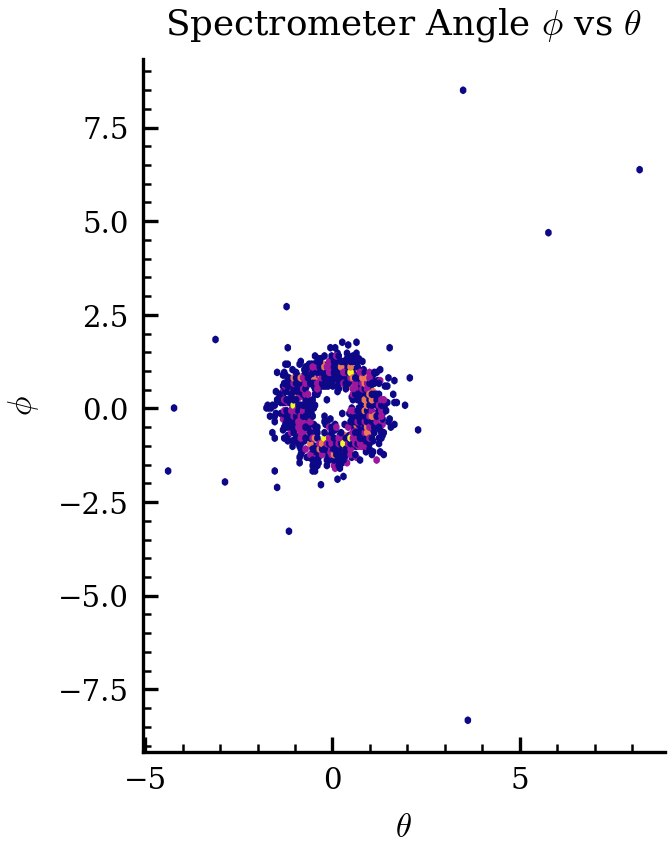

In [3]:
# plt.hexbin(Thetalab_recoil_gate_test, E_recoil_0MeV_gate_test, gridsize=1000, mincnt=1)
# plt.hexbin(Thetalab_t_gate_test, E_t_gate_test, gridsize=100, mincnt=1)
fig = plt.figure(figsize=(5,3))
plt.hexbin(theta, phi, gridsize=200, mincnt=1, cmap="plasma")
plt.title(r"Spectrometer Angle $\phi$ vs $\theta$")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\phi$")
plt.gca().set_aspect('equal', adjustable='box')
autoscale_fonts(fig, base=10)
# plt.xlim(-7.5, 8)
# plt.ylim(-7, 9)



# plt.savefig("OuterMostAngleMap.png")

In [4]:
Thetalab_recoil_rad = np.deg2rad(Thetalab_recoil_gate_test)
Philab_recoil_rad = np.deg2rad(Philab_recoil_gate_test)
print(len(Thetalab_recoil_rad))

bins = 100
# edges = 1000
edges = np.linspace(-4.2, 4.2, 100)
# Phi = np.arctan2(uy, ux)
# plt.hist(np.arctan2(uy, ux), bins = 100)
fig = plt.figure(figsize=(4, 3))
# theta = np.arctan2(np.tan(Thetalab_recoil_rad) * np.cos(Philab_recoil_rad), np.cos(Thetalab_recoil_rad))  # in radians 
# phi = np.arctan2(np.tan(Thetalab_recoil_rad) * np.sin(Philab_recoil_rad), np.cos(Thetalab_recoil_rad))    # in radians 
theta = np.arctan(np.tan(Thetalab_recoil_rad) * np.cos(Philab_recoil_rad))
phi = np.arctan(np.tan(Thetalab_recoil_rad) * np.sin(Philab_recoil_rad))

# lo = min(theta.min(), phi.min())
# hi = max(theta.max(), phi.max())
# edges = np.linspace(lo, hi, bins + 1)

plt.hist(np.rad2deg(theta), bins=edges, histtype="step", linewidth=0.5, label=r"$\theta$")
plt.hist(np.rad2deg(phi), bins = edges, histtype="step", linewidth=0.5,label = r"$\phi$")
plt.xlabel("degree")
plt.ylabel("counts")
plt.title(r"Distribution of $\phi$ and $\theta$, outermost ring [$131.32 \degree$, $132.21 \degree$], $E_x = 11MeV$")
plt.legend()
# print(sum(counts))
# print(sum(counts2))

# len(Philab_recoil_rad)
# plt.hexbin(theta, phi, gridsize=100, mincnt=1)

autoscale_fonts(fig, base=10)

# print([:10])
# plt.savefig("OuterMostRing.png")





NameError: name 'Thetalab_recoil_gate_test' is not defined

In [ ]:
# plt.hexbin(Thetalab_recoil_gate_test, E_recoil_0MeV_gate_test, gridsize=1000, mincnt=1)
# plt.hexbin(Thetalab_t_gate_test, E_t_gate_test, gridsize=100, mincnt=1)
fig = plt.figure(figsize=(5,3))
plt.hexbin(np.rad2deg(theta), np.rad2deg(phi), gridsize=200, mincnt=1, cmap="plasma")
plt.title(r"Spectrometer Angle $\phi$ vs $\theta$")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\phi$")
plt.gca().set_aspect('equal', adjustable='box')
autoscale_fonts(fig, base=10)
# plt.savefig("OuterMostAngleMap.png")
plt.xlim(-7.5, 8)
plt.ylim(-7, 9)


NameError: name 'theta' is not defined

<Figure size 1500x900 with 0 Axes>

In [26]:
test = np.loadtxt("S3_triton_ring_observables.dat", delimiter=",", skiprows=1).astype(float)
Ebeam = test[:, 0]
E_target = test[:, 1] + test[:, -1] # energy exiting target  
Theta_target = test[:, 2]
Phi_target = test[:, 3]
E_dep = test[:, 4] + test[:, -1]
Theta_dep = test[:, 5]
Phi_dep = test[:, 6]
E_rec = test[:, 7]
Theta_rec = test[:, 8]
Phi_rec = test[:, 9]
loss = test[:, -1]
E_smear = test[:, -2] + loss

# target = np.loadtxt("triton_target_exit_observables.dat", delimiter=",", skiprows=1).astype(float)
# Ebeam1 = target[:, 0]
# E_t_target = target[:, 1]
# Theta_t_target = target[:, 2]


In [45]:
# edges = np.linspace(min(E_rec), max(E_rec), 300)
# fig, ax  = plt.subplots(1, figsize=(5, 3))
# ax.hist(E_target, bins = edges, histtype="step", linewidth=0.5, label="Target Exit")
# ax.hist(E_dep, bins = edges, histtype="step", linewidth=0.5, label="S3 Energy Deposition")
# ax.hist(E_rec, bins = edges, histtype="step", linewidth=0.5,label = "Reaction Point")
# ax.set_title("Triton Energy Distribution(Ring 24, Ex = 0)" )
# ax.set_xlabel("Energy [MeV]")
# ax.set_ylabel("Counts")
# ax.legend()
# # ax.set_xbound(0, 10)
# autoscale_fonts(fig, base=10)
# prettify(ax)
    

# plt.savefig("TritonEnergyRing24(Ex=0MeV).png")


10000
10000
10000
9978.0
10000.0
10000.0


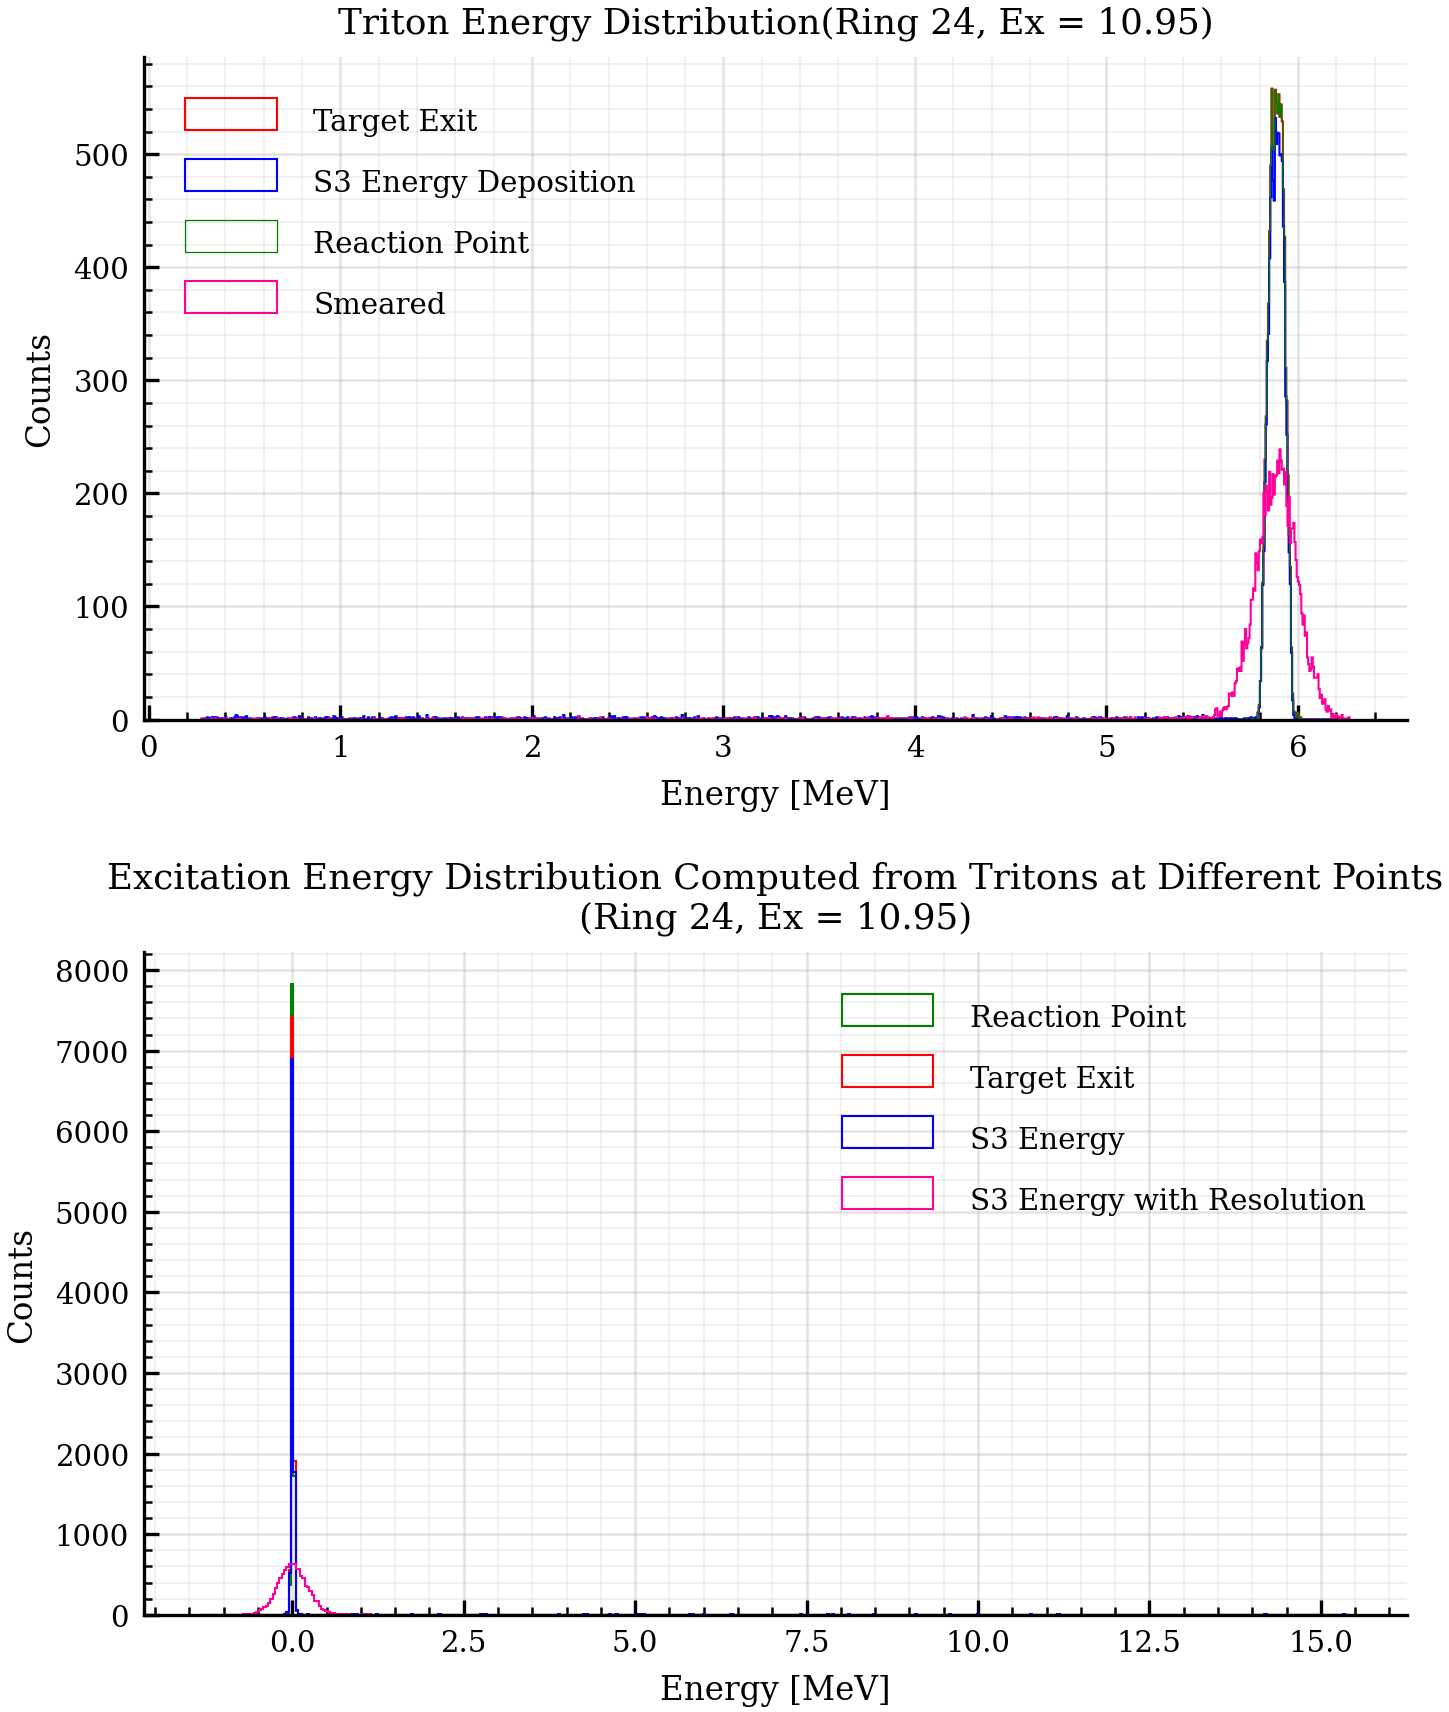

In [28]:
# Triton Energy inspection
edges = np.linspace(min(E_smear), max(E_smear), 1000)
fig, ax  = plt.subplots(2, figsize=(5, 6))
counts_target, bins_target, patches = ax[0].hist(E_target, bins = edges, histtype="step", linewidth=0.5, label="Target Exit", color = 'red')
counts_dep, bins_dep, patches = ax[0].hist(E_dep, bins = edges, histtype="step", linewidth=0.5, label="S3 Energy Deposition", color = 'blue')
counts_rec, bins_rec, patches = ax[0].hist(E_rec, bins = edges, histtype="step", linewidth=0.3,label = "Reaction Point", color = 'green')
counts_smear, bin_smear, patches = ax[0].hist(E_smear, bins = edges, histtype="step", linewidth=0.5,label = "Smeared", color = "#FE019A")
ax[0].set_title("Triton Energy Distribution(Ring 24, Ex = 10.95)" )
ax[0].set_xlabel("Energy [MeV]")
ax[0].set_ylabel("Counts")
ax[0].legend()
# ax[0].set_xlim(min(E_rec) - 0.3 , max(E_rec))
# ax.set_xbound(0, 10)
autoscale_fonts(fig, base=10)
prettify(ax[0])

# plt.savefig("ExEngRing24Ex0.png")

# Excitation Energy
mA = 20484.845566 #MeV
ma = 6535.365833
mb = 2809.432119
mB = 24202.632149
def calc_exc(Ebeam, E_t, Thetalab, mA, ma, mb, mB):
    T = Ebeam
    val1 = mA**2 + ma**2 + mb**2 + 2 * mA * ma + 2 * ma * T
    val2 = -2 * (mb + E_t) * (mA + T + ma)
    val3 = 2 * np.cos(np.deg2rad(Thetalab)) * np.sqrt(T**2 + 2 * mA * T) * np.sqrt(E_t**2 + 2 * mb * E_t)
    Exc = np.sqrt(val1 + val2 + val3) - mB
    return Exc
    
# Exc = calc_exc(Ebeam, E_t_gen, Theta_t_gen, mA, ma, mb, mB)
Exc_dep = calc_exc(Ebeam, E_dep, Theta_dep, mA, ma, mb, mB)
Exc_rec = calc_exc(Ebeam, E_rec, Theta_rec, mA, ma, mb, mB)
Exc_target = calc_exc(Ebeam, E_target, Theta_target, mA, ma, mb, mB)
Exc_smear = calc_exc(Ebeam, E_smear, Theta_dep, mA, ma, mb, mB)


bins = np.linspace(min(Exc_smear)-0.5, max(Exc_smear), 500)
# fig = plt.figure(figsize=(5, 3))
# fig, ax = plt.subplots(1, figsize = (5, 3))
ax[1].hist(Exc_rec, bins = bins, histtype="step", linewidth=0.5,label = "Reaction Point", color = 'green')
ax[1].hist(Exc_target, bins = bins, histtype="step", linewidth=0.5,label = "Target Exit", color = 'red')
ax[1].hist(Exc_dep, bins = bins, histtype="step", linewidth=0.5,label = "S3 Energy", color = 'blue')
ax[1].hist(Exc_smear, bins = bins, histtype="step", linewidth=0.5,label = "S3 Energy with Resolution", color = "#FE019A")
ax[1].set_title("Excitation Energy Distribution Computed from Tritons at Different Points\n(Ring 24, Ex = 10.95)")
ax[1].set_xlabel("Energy [MeV]")
ax[1].set_ylabel("Counts")
# ax[1].set_xlim(-0.5, 0.5)
ax[1].legend()
# ax.legend()
prettify(ax[1])
# plt.xlim(9.5, 12.5)
# plt.ylim(0, 300)


print(len(Exc_dep))
print(len(Exc_rec))
print(len(Exc_target))
autoscale_fonts(fig, base=10)
plt.tight_layout()

# plt.savefig("Ex10pt95Ring24.png")

print(sum(counts_dep))
print(sum(counts_rec))
print(sum(counts_target))

    
    

In [22]:
# # Excitation Energy
# mA = 20484.845566 #MeV
# ma = 6535.365833
# mb = 2809.432119
# mB = 24202.632149

# # if len(Ebeam) != len(E_t_gate_test):
# #     diff = len(Ebeam) - len(E_t_gate_test)
# #     if diff > 0: 
# #         Ebeam = Ebeam[:-diff]
# #     else: 
# #         E_t_gate_test = E_t_gate_test[:diff]
# #     # E_t_gate_test = E_t_gate_test[:-1]
# T = Ebeam
# # T = 66
# print(len(Ebeam))
# # print(len(E_t_gate_test))

# val1 = mA**2 + ma**2 + mb**2 + 2 * mA * ma + 2 * ma * T
# val2 = -2 * (mb + E_rec) * (mA + T + ma)
# val3 = 2 * np.cos(np.deg2rad(Theta_rec)) * np.sqrt(T**2 + 2 * mA * T) * np.sqrt(E_rec**2 + 2 * mb * E_rec)
# Exc = np.sqrt(val1 + val2 + val3) - mB
# bins = np.linspace(min(Exc), max(Exc), 1000)
# # fig = plt.figure(figsize=(5, 3))
# fig, ax = plt.subplots(1, figsize = (5, 3))
# ax.hist(Exc, bins = bins, histtype="step", linewidth=0.5,label = r"$\phi$")
# ax.set_title("Excitation Energy Distribution (Ex = 0, Ring 24)")
# ax.set_xlabel("Energy [MeV]")
# ax.set_ylabel("Counts")
# # ax.set_xlim(-1, 1)
# # ax.legend()
# prettify(ax)
# # plt.xlim(10.6, 11.5)
# autoscale_fonts(fig, base=10)
# # plt.savefig("Ring 12 Ex = 0MeV")




In [37]:
# Maximum likelihood fit 
Exc = Exc_smear 
def gauss_pdf(e, sigma, E): 
    return stats.norm.pdf(e, loc = E, scale = sigma)

# def nll(sigma, E):
#     likelihood = gauss_pdf(Exc, sigma, E)
#     return -np.sum(np.log(likelihood))
n = 0.7
hi = np.mean(Exc) + n * np.std(Exc)
lo = np.mean(Exc) - n * np.std(Exc)
# hi = 10.9
# lo = 10.98

print(len(Exc))
# hi = 10.8
# lo = 11.5
Exc = Exc[(Exc > lo) & (Exc < hi)]
print(len(Exc))
# def nll(sigma, E, f):
def nll(sigma, E):
    # truncated Gaussian on [lo, hi]
    # if sigma <= 0 or f <= 0 or f >= 1:
    #     return 1e50
    # NORMALIZATION! 
    Z = stats.norm.cdf(hi, loc = E, scale=sigma) - stats.norm.cdf(lo, loc=E, scale=sigma)
    if (not np.isfinite(Z)) or (Z <= 0):
        return 1e50
    
    logS = stats.norm.logpdf(Exc, loc=E, scale=sigma) - np.log(Z) # signal log-pdf in window
    logB = -np.log(hi - lo)
    # ll = np.log(f * gauss_pdf(Exc, sigma, E) / Z + (1-f) * 1 / (hi - lo))
    # return -np.sum(np.logaddexp(np.log(f) + logS, np.log(1 - f) + logB))
    return -np.sum(logS)
# initial guesses: 
sigma_guess = np.std(Exc)
E_guess = np.mean(Exc)
# f_guess = 0.8
# minimization
N = Exc.size
# m = Minuit(nll, sigma = sigma_guess, E = E_guess, f = f_guess)
m = Minuit(nll, sigma = sigma_guess, E = E_guess)
# ensure positivity
m.limits["sigma"]  = (1e-9, None) 
# specify likelihood levels 
m.errordef = Minuit.LIKELIHOOD
m.migrad()
sigma_hat = m.values["sigma"]
E_hat = m.values["E"]
# f_hat = m.values["f"]
m.hesse()



10000
9735


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1461                      │              Nfcn = 40               │
│ EDM = 4.28e-06 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ sigma │  0.2132   │  0.0017   │            │            │  1e-09  │         │       │
│ 1 │ E     │  0.0040   │  0.0022   │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬───────────────────┐
│       │    sigma        E │
├───────┼───────────────────┤
│ sigma │ 2.77e-06  -0.3e-6 │
│     E │  -0.3e-6 4.88e-06 │
└───────┴───────────────────┘

<>:60: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:60: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/jr/p39hf4vd6lg896bktf3v_y800000gn/T/ipykernel_63401/2674537750.py:60: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  0.05, 0.98, f"$E_x$ = {E_hat:.3g}[MeV] \n$\sigma$ = {sigma_hat:.3g}[MeV]",


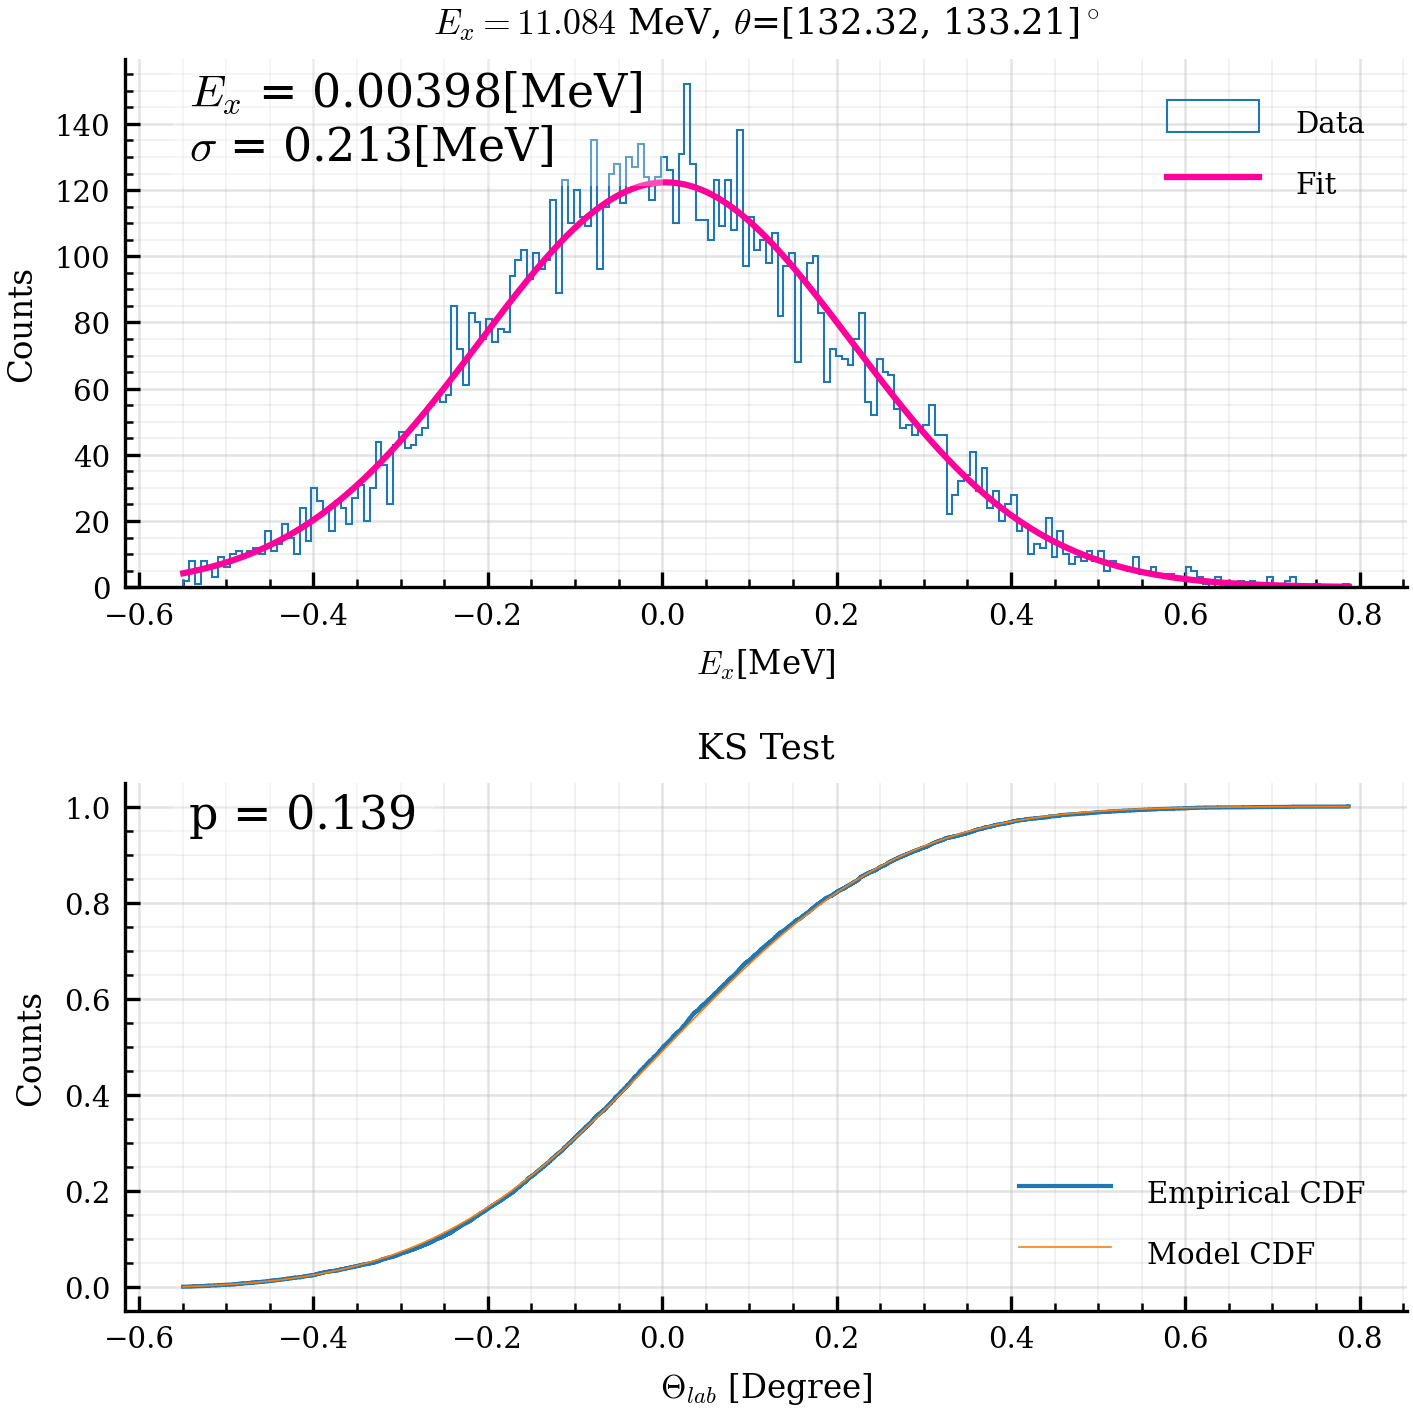

In [38]:
fig, ax = plt.subplots(2, figsize = (5, 5))
bins = 200
e = np.linspace(min(Exc), max(Exc), 10000)
counts, edges, patches = ax[0].hist(Exc, bins = bins, histtype="step", linewidth=0.5,label = r"Data")
bin_width = edges[1] - edges[0]

# NORMALIZATION! 
Z = stats.norm.cdf(hi, loc = E_hat, scale = sigma_hat) - stats.norm.cdf(lo, loc = E_hat, scale = sigma_hat)
signal_density = stats.norm.pdf(e, loc=E_hat, scale=sigma_hat) / Z
bkg_density = 1.0 / (hi - lo)

# expected_counts = N * bin_width * (f_hat * signal_density + (1 - f_hat) * bkg_density)
expected_counts = N * bin_width * signal_density

ax[0].plot(e, expected_counts, color = "#FE019A", label = "Fit")
# plt.xlim(11, 11.4)
# plt.savefig("fit.png")

# KS test: 
def model_cdf(t):
    """CDF of mixture on [lo,hi]: f*truncNorm + (1-f)*Uniform."""
    t = np.asarray(t, dtype=float)
    out = np.empty_like(t)

    out[t <= lo] = 0.0
    out[t >= hi] = 1.0

    mask = (t > lo) & (t < hi)
    tt = t[mask]

    # NORMALIZATION! truncated Gaussian CDF on [lo,hi]
    Fs = (stats.norm.cdf(tt, loc=E_hat, scale=sigma_hat) - stats.norm.cdf(lo, loc=E_hat, scale=sigma_hat)) / Z
    # uniform CDF on [lo,hi]
    Fb = (tt - lo) / (hi - lo)

    # out[mask] = f_hat * Fs + (1.0 - f_hat) * Fb
    out[mask] = Fs
    return out

D, p = stats.kstest(Exc, model_cdf)

xs = np.sort(Exc)
ecdf = np.arange(1, N + 1) / N

ax[1].step(xs, ecdf, where="post", linewidth=1.0, label="Empirical CDF")
ax[1].plot(e, model_cdf(e), linewidth=0.4, label="Model CDF")

ax[1].set_ylabel("CDF")
ax[1].set_xlabel(r"$\Theta_{lab}$ [Degree]")  # change label if Exc is energy
ax[1].legend()

ax[1].text(
    0.05, 0.98, f"p = {p:.3g}",
    transform=ax[1].transAxes,  # <= scale-independent
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.3, edgecolor="none")
)

ax[0].text(
    0.05, 0.98, f"$E_x$ = {E_hat:.3g}[MeV] \n$\sigma$ = {sigma_hat:.3g}[MeV]",
    transform=ax[0].transAxes,  # <= scale-independent
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.3, edgecolor="none")
)

# ax[0].set_xlim(7.9, 8.2)
for i in ax.ravel(): 
    prettify(i)
    i.legend()
    # i.set_xlabel(r"$\Theta_{lab}$[Degree]")
    i.set_ylabel("Counts")
    # i.set_xbound(-15, 15)
    
ax[0].set_title(
            rf"$E_x={11.084:.3f}$ MeV, $\theta$=[{132.32:.2f}, {133.21:.2f}]$^\circ$"
        )
ax[0].set_xlabel(r"$E_x$[MeV]")


ax[1].set_title("KS Test")
    
autoscale_fonts(fig, base=10)
plt.tight_layout()
plt.savefig("OneFit.png")



Text(0, 0.5, 'Counts')

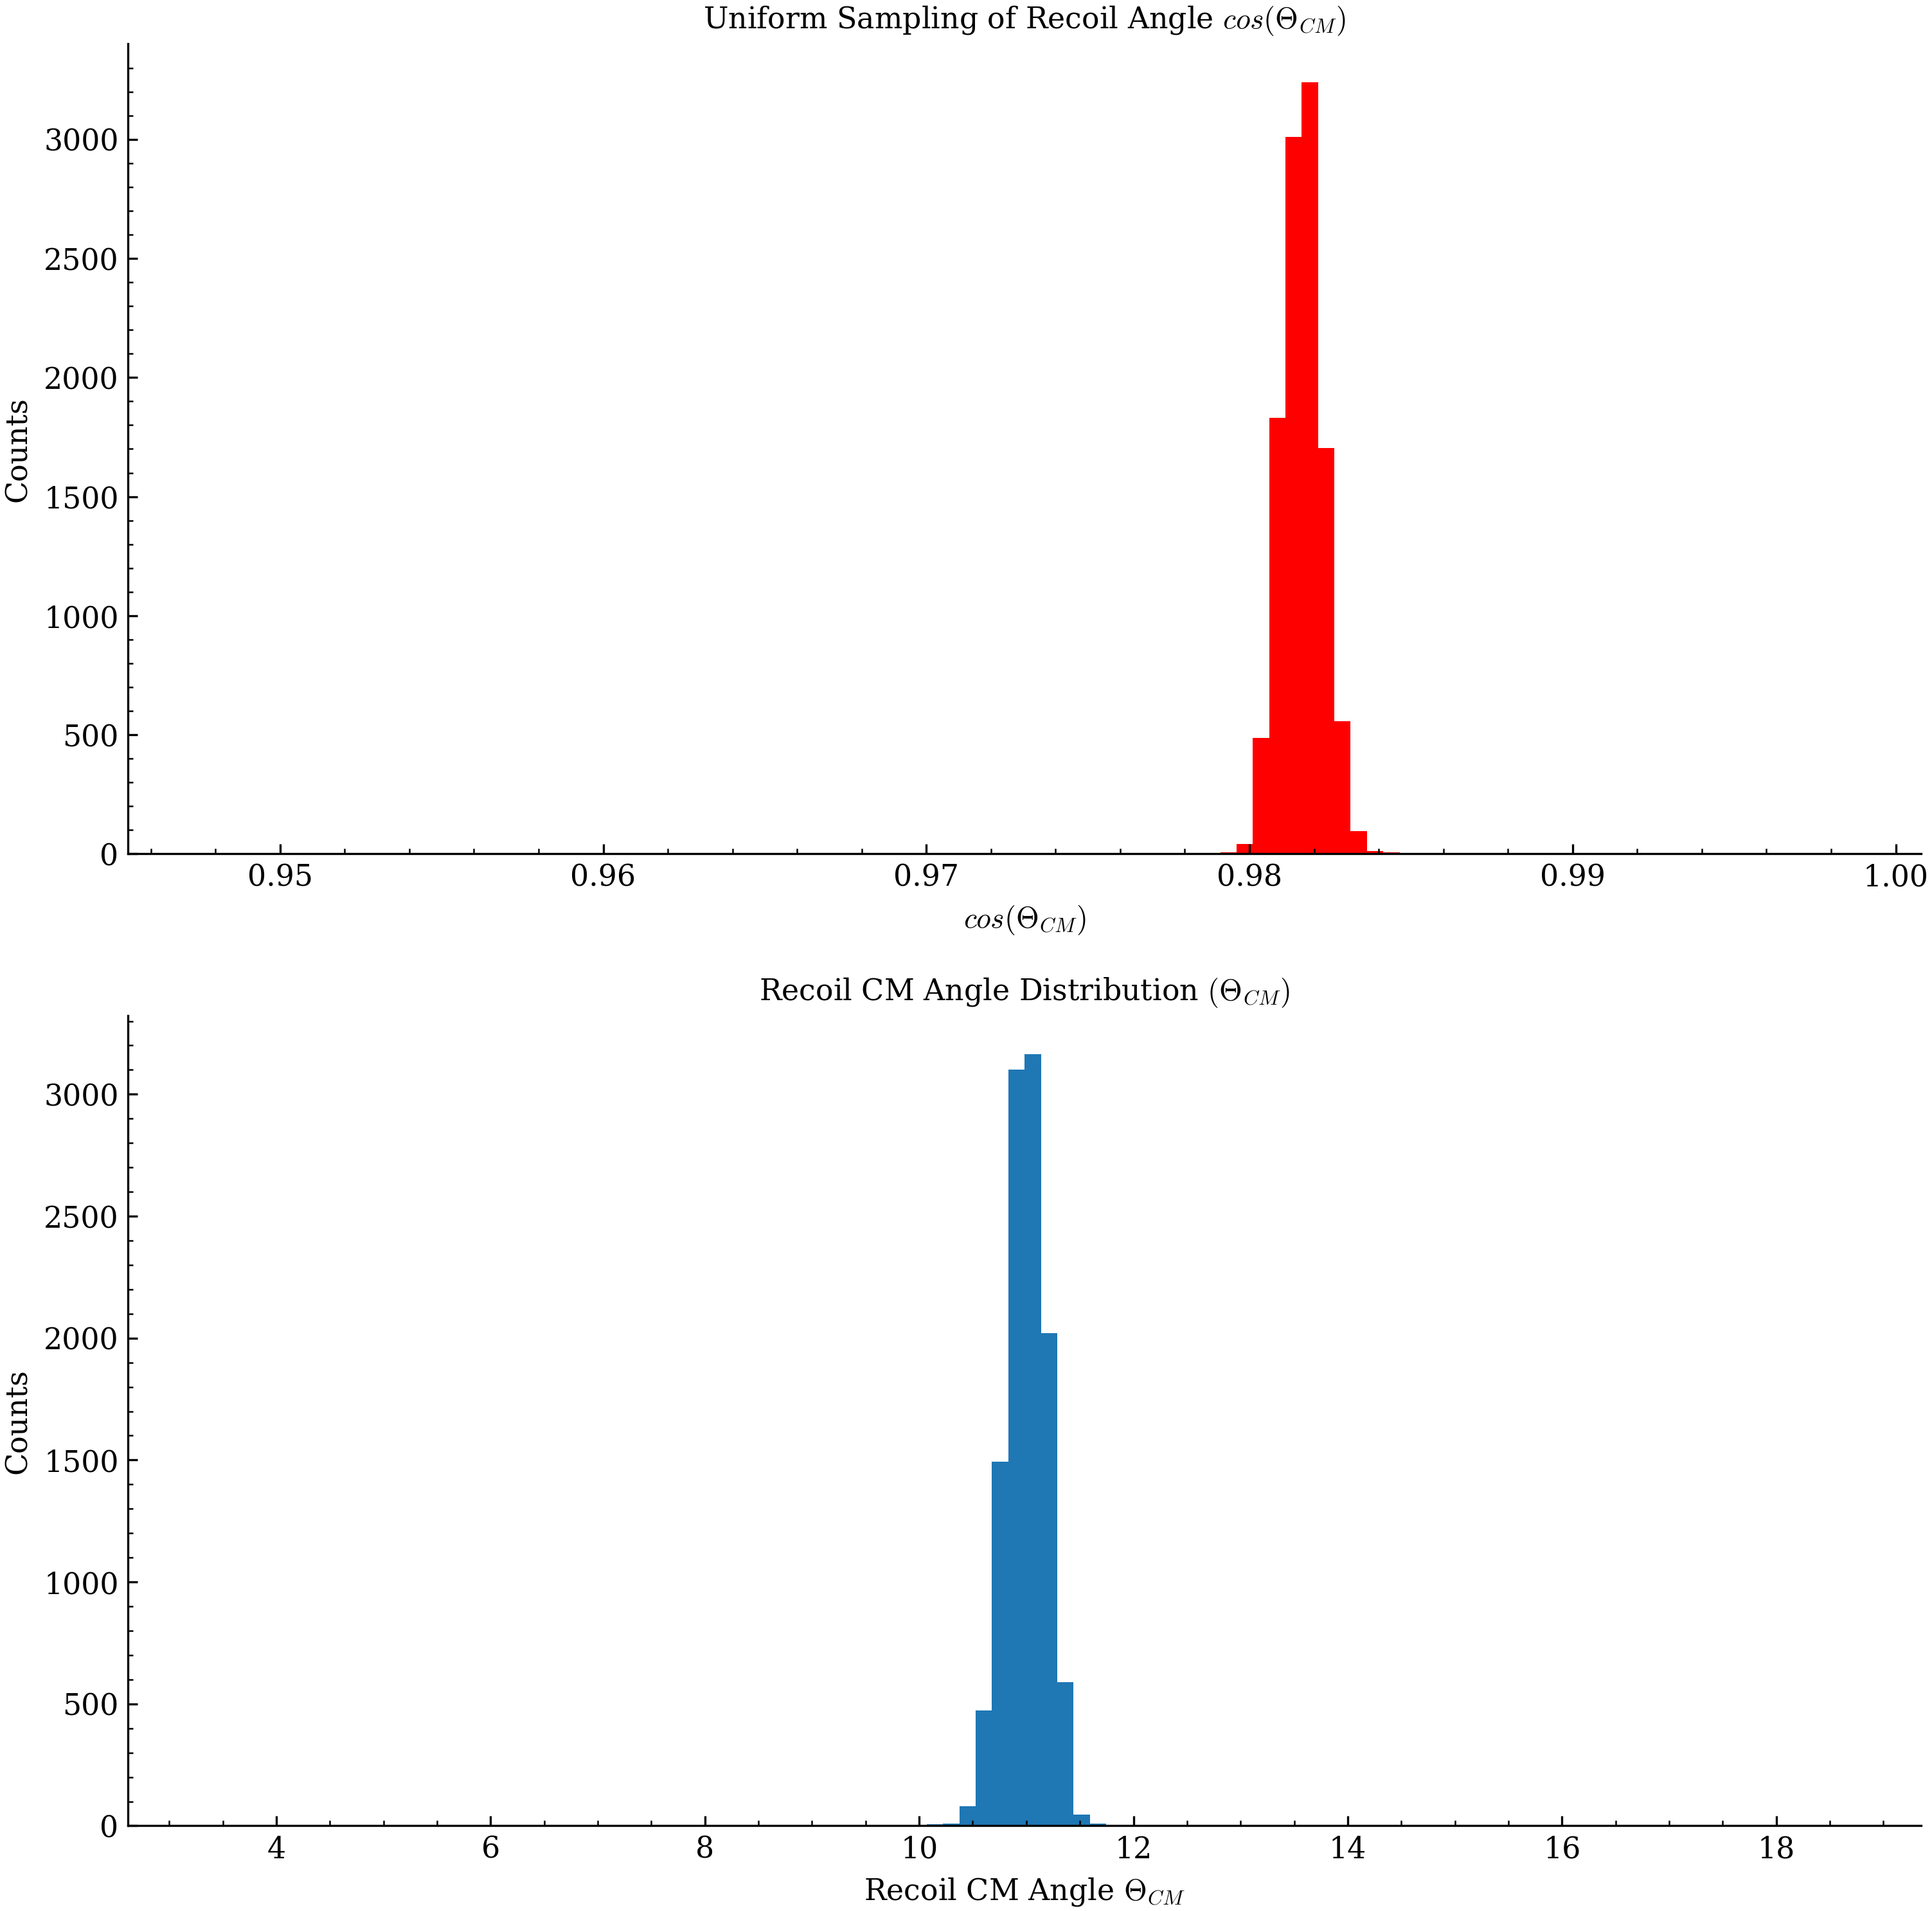

In [ ]:
bins = 100
# plt.hist(Thetalab_t, bins = bins)
fig, ax = plt.subplots(2, figsize=(12, 12))

# Monte Carlo draws isotropic samples (uniform in cos(ThetaCM))
# ax[0].hist(np.cos(np.deg2rad(ThetaCM_recoil_11MeV)), bins = bins, color = 'red')
ax[0].hist(np.cos(np.deg2rad(ThetaCM_recoil_gate_test)), bins = bins, color = 'red')
ax[0].set_title(r"Uniform Sampling of Recoil Angle $cos(\Theta_{CM})$")
ax[0].set_xlabel(r"$cos(\Theta_{CM})$")
ax[0].set_ylabel("Counts")
ax[1].hist(ThetaCM_recoil_gate_test, bins = bins)

ax[1].set_title(r"Recoil CM Angle Distribution $(\Theta_{CM})$")
ax[1].set_xlabel(r"Recoil CM Angle $\Theta_{CM}$")
ax[1].set_ylabel("Counts")
# plt.savefig("SamplingDistributionCheck.png")




NameError: name 'Thetalab_t_11MeV' is not defined

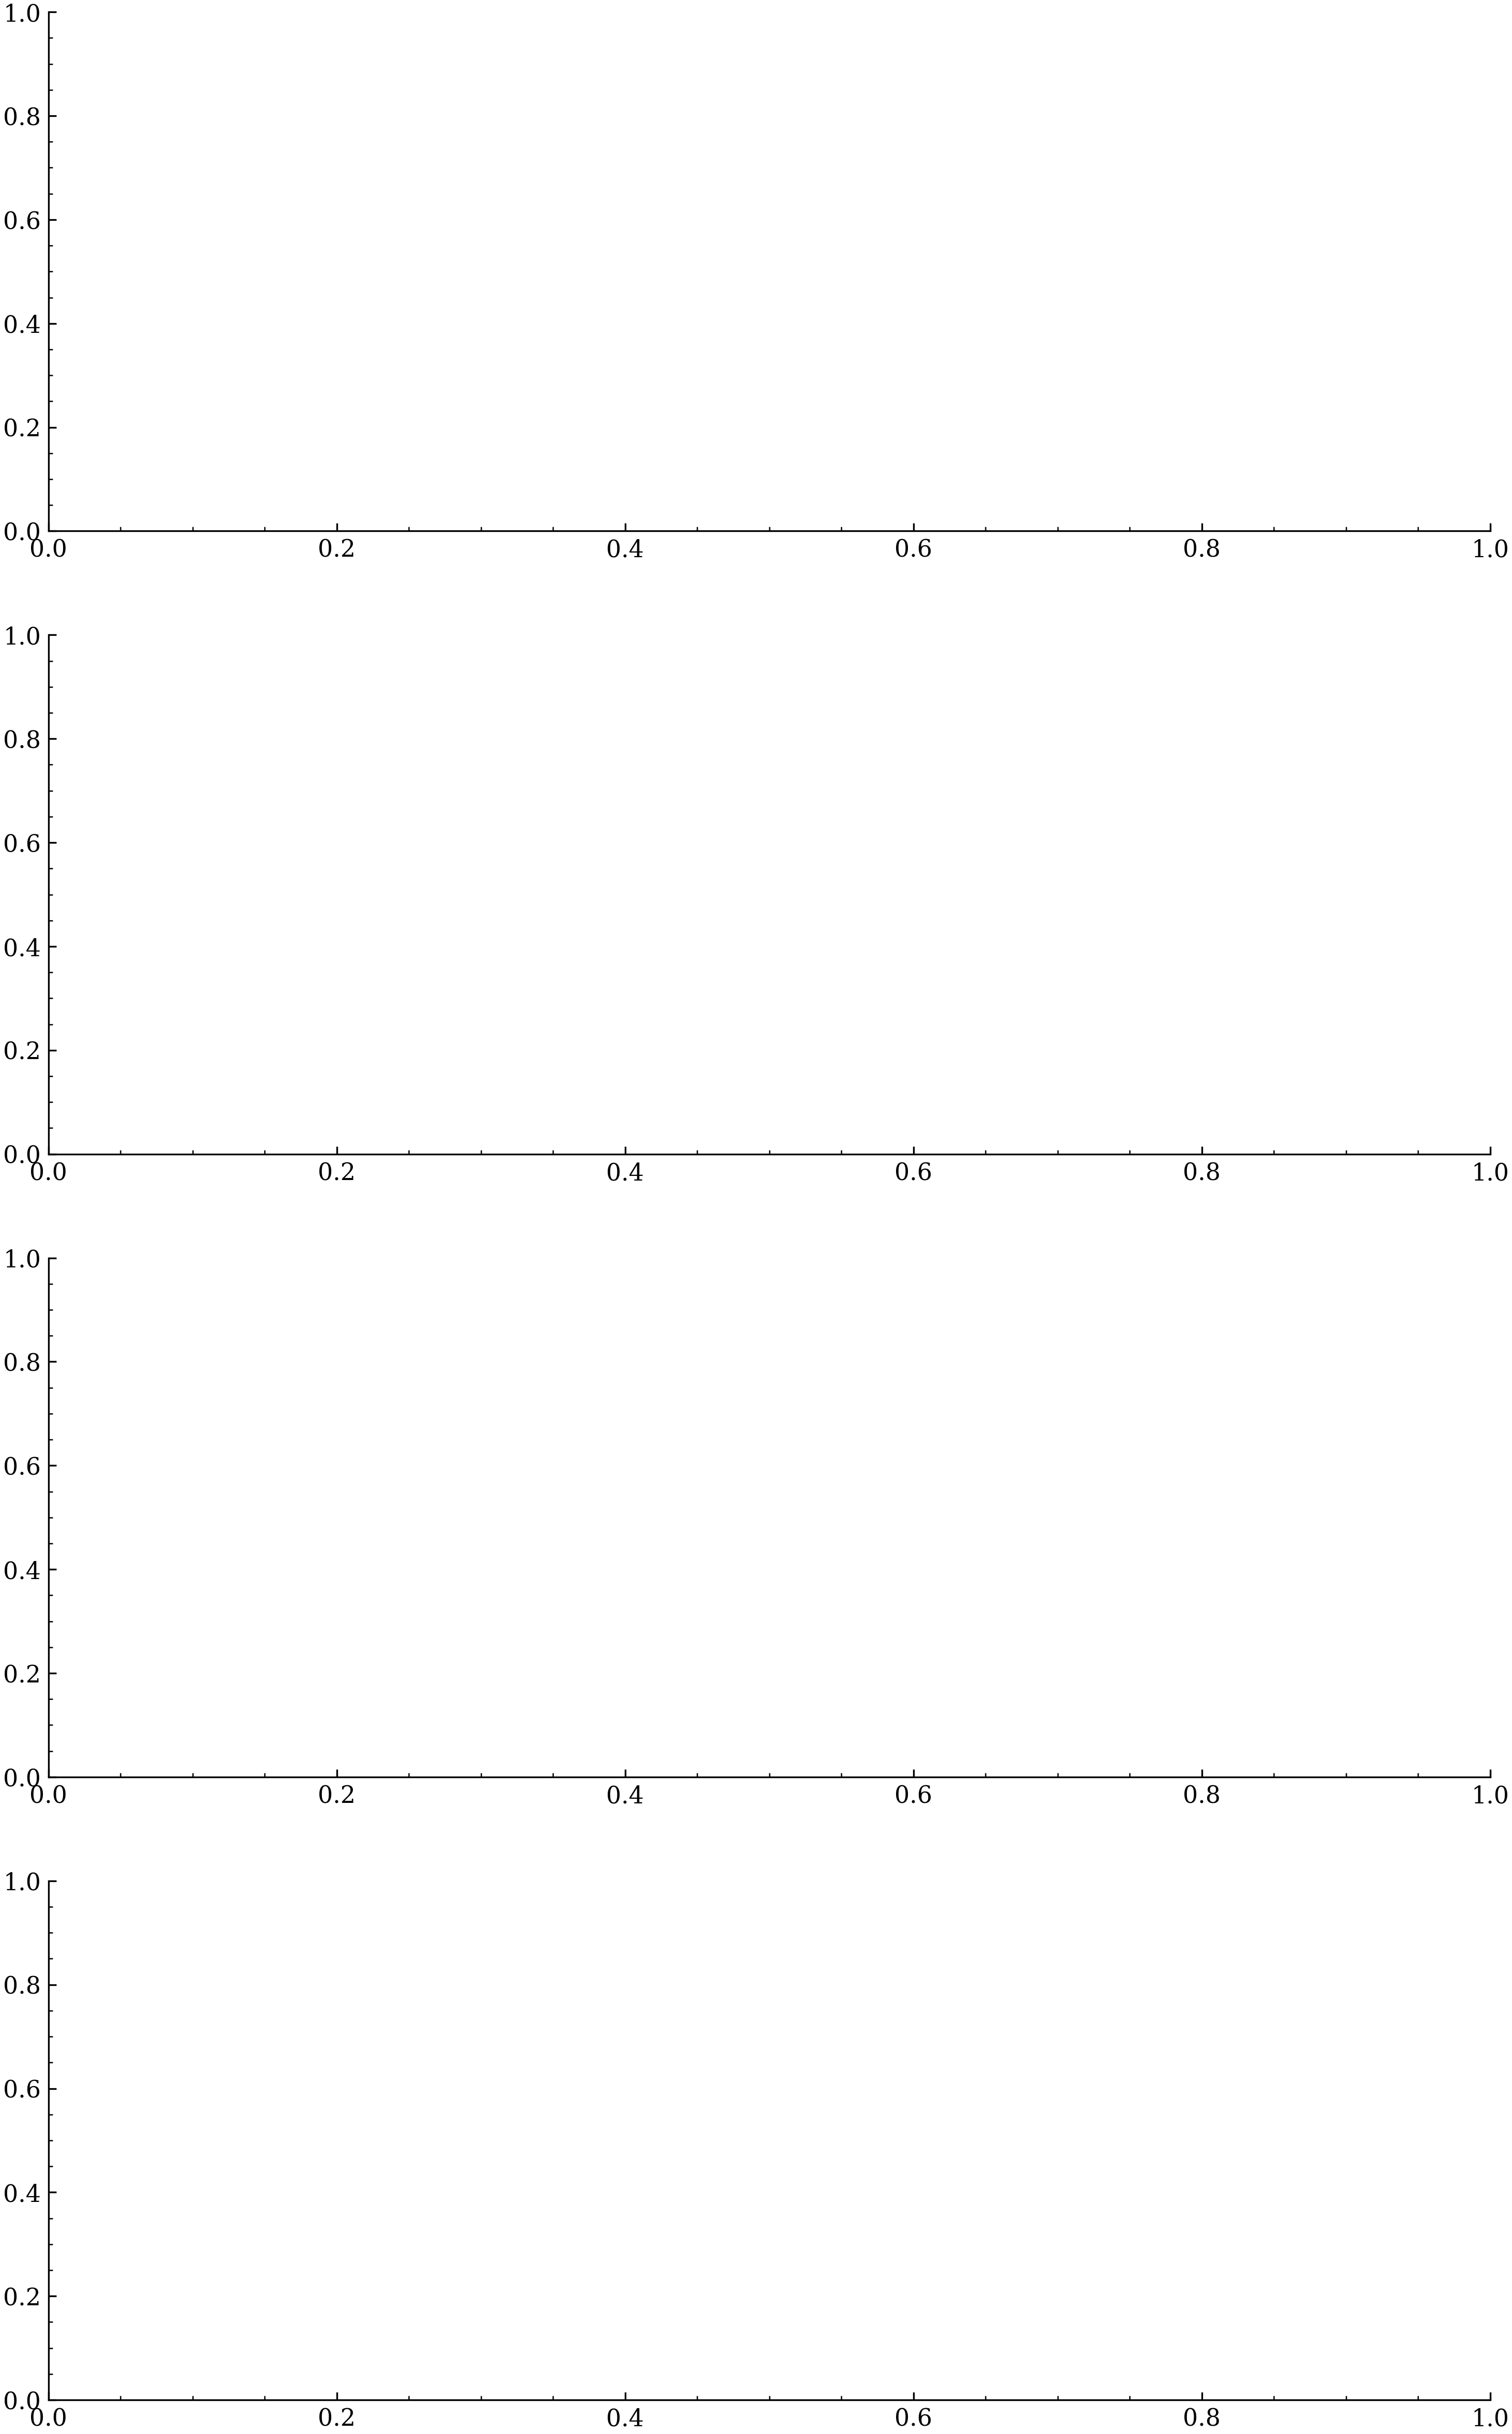

In [ ]:
# Checking
fig, ax = plt.subplots(4, figsize=(12, 20))
ax[0].hexbin(Thetalab_t_11MeV, E_t_11MeV, gridsize=200, cmap="plasma", mincnt=1, label="Triton")
ax[0].hexbin(Thetalab_t_4MeV, E_t_4MeV, gridsize=200, mincnt=1, label="Triton")
ax[0].set_xlabel(r"Lab Angle $\Theta_{lab}$ [Degrees]")
ax[0].set_ylabel("Lab Energy [MeV]")
ax[0].set_title("Lab Energy vs Lab Angle")
ax[0].hexbin(Thetalab_recoil_11MeV, E_recoil_11MeV, gridsize=200, cmap = "plasma", mincnt=1, label="Recoil")
ax[0].hexbin(Thetalab_recoil_4MeV, E_recoil_4MeV, gridsize=200, mincnt=1, label="Recoil")

# ax[0].set_xlim(130, 160)
counts, edges, patches = ax[1].hist(Thetalab_t_11MeV, bins = bins)
ax[1].hist(ThetaCM_t_4MeV, bins = bins)

ax[1].set_xlabel(r"$\Theta_{lab}$")
ax[1].set_ylabel("Counts")
ax[1].set_title("Triton Lab Angle Distribution")
ax[2].hist(ThetaCM_t_11MeV, bins = bins)
ax[2].hist(ThetaCM_t_4MeV, bins = bins)
ax[2].set_xlabel(r"$\Theta_{CM}$")
ax[2].set_ylabel("Counts")
ax[2].set_title("Triton CM Angle Distribution")
ax[3].hist((1 - np.cos(np.deg2rad(ThetaCM_t_11MeV)))/2, bins = bins)
ax[3].set_xlabel(r"$cos(\Theta_{CM})$")
ax[3].set_ylabel("Counts")
ax[3].set_title(r"Triton Solid Angle Distribution $cos(\Theta_{CM})$")
plt.tight_layout()


In [ ]:
# Check individual rings

# S3 detector info, radii[mm]
outer = 35 
inner = 11
width = 1
dist = 31 # target to S3 distance
rings = np.arange(inner, outer + 1) # rings radii 
ring_dtheta = np.rad2deg(np.arctan(rings[1:] / dist) - np.arctan(rings[: -1] / dist)) # [inner, ... outer]
outer_theta = np.rad2deg(np.pi) - np.rad2deg(np.arctan(outer / dist))   # outermost ring, should be 131 degree 
rings_theta = np.zeros(24)
for i in range(len(ring_dtheta)): 
    acc = outer_theta + ring_dtheta[-i]
    rings_theta[-i-1] = outer_theta + np.sum(ring_dtheta[-i-1:])
    
# flip
rings_theta = rings_theta[::-1]  # angles for each ring boundary
print(rings_theta)
print(ring_dtheta[-1] + outer_theta)


[132.35745471 133.21008939 134.09061955 135.         135.93919095
 136.90915243 137.91083783 138.94518623 140.01311376 141.11550357
 142.25319461 143.42696902 144.63753811 145.88552705 147.17145821
 148.49573328 149.85861445 151.26020471 152.70042779 154.17900803
 155.69545073 157.24902366 158.83874018 160.46334506]
132.35745470593528


82


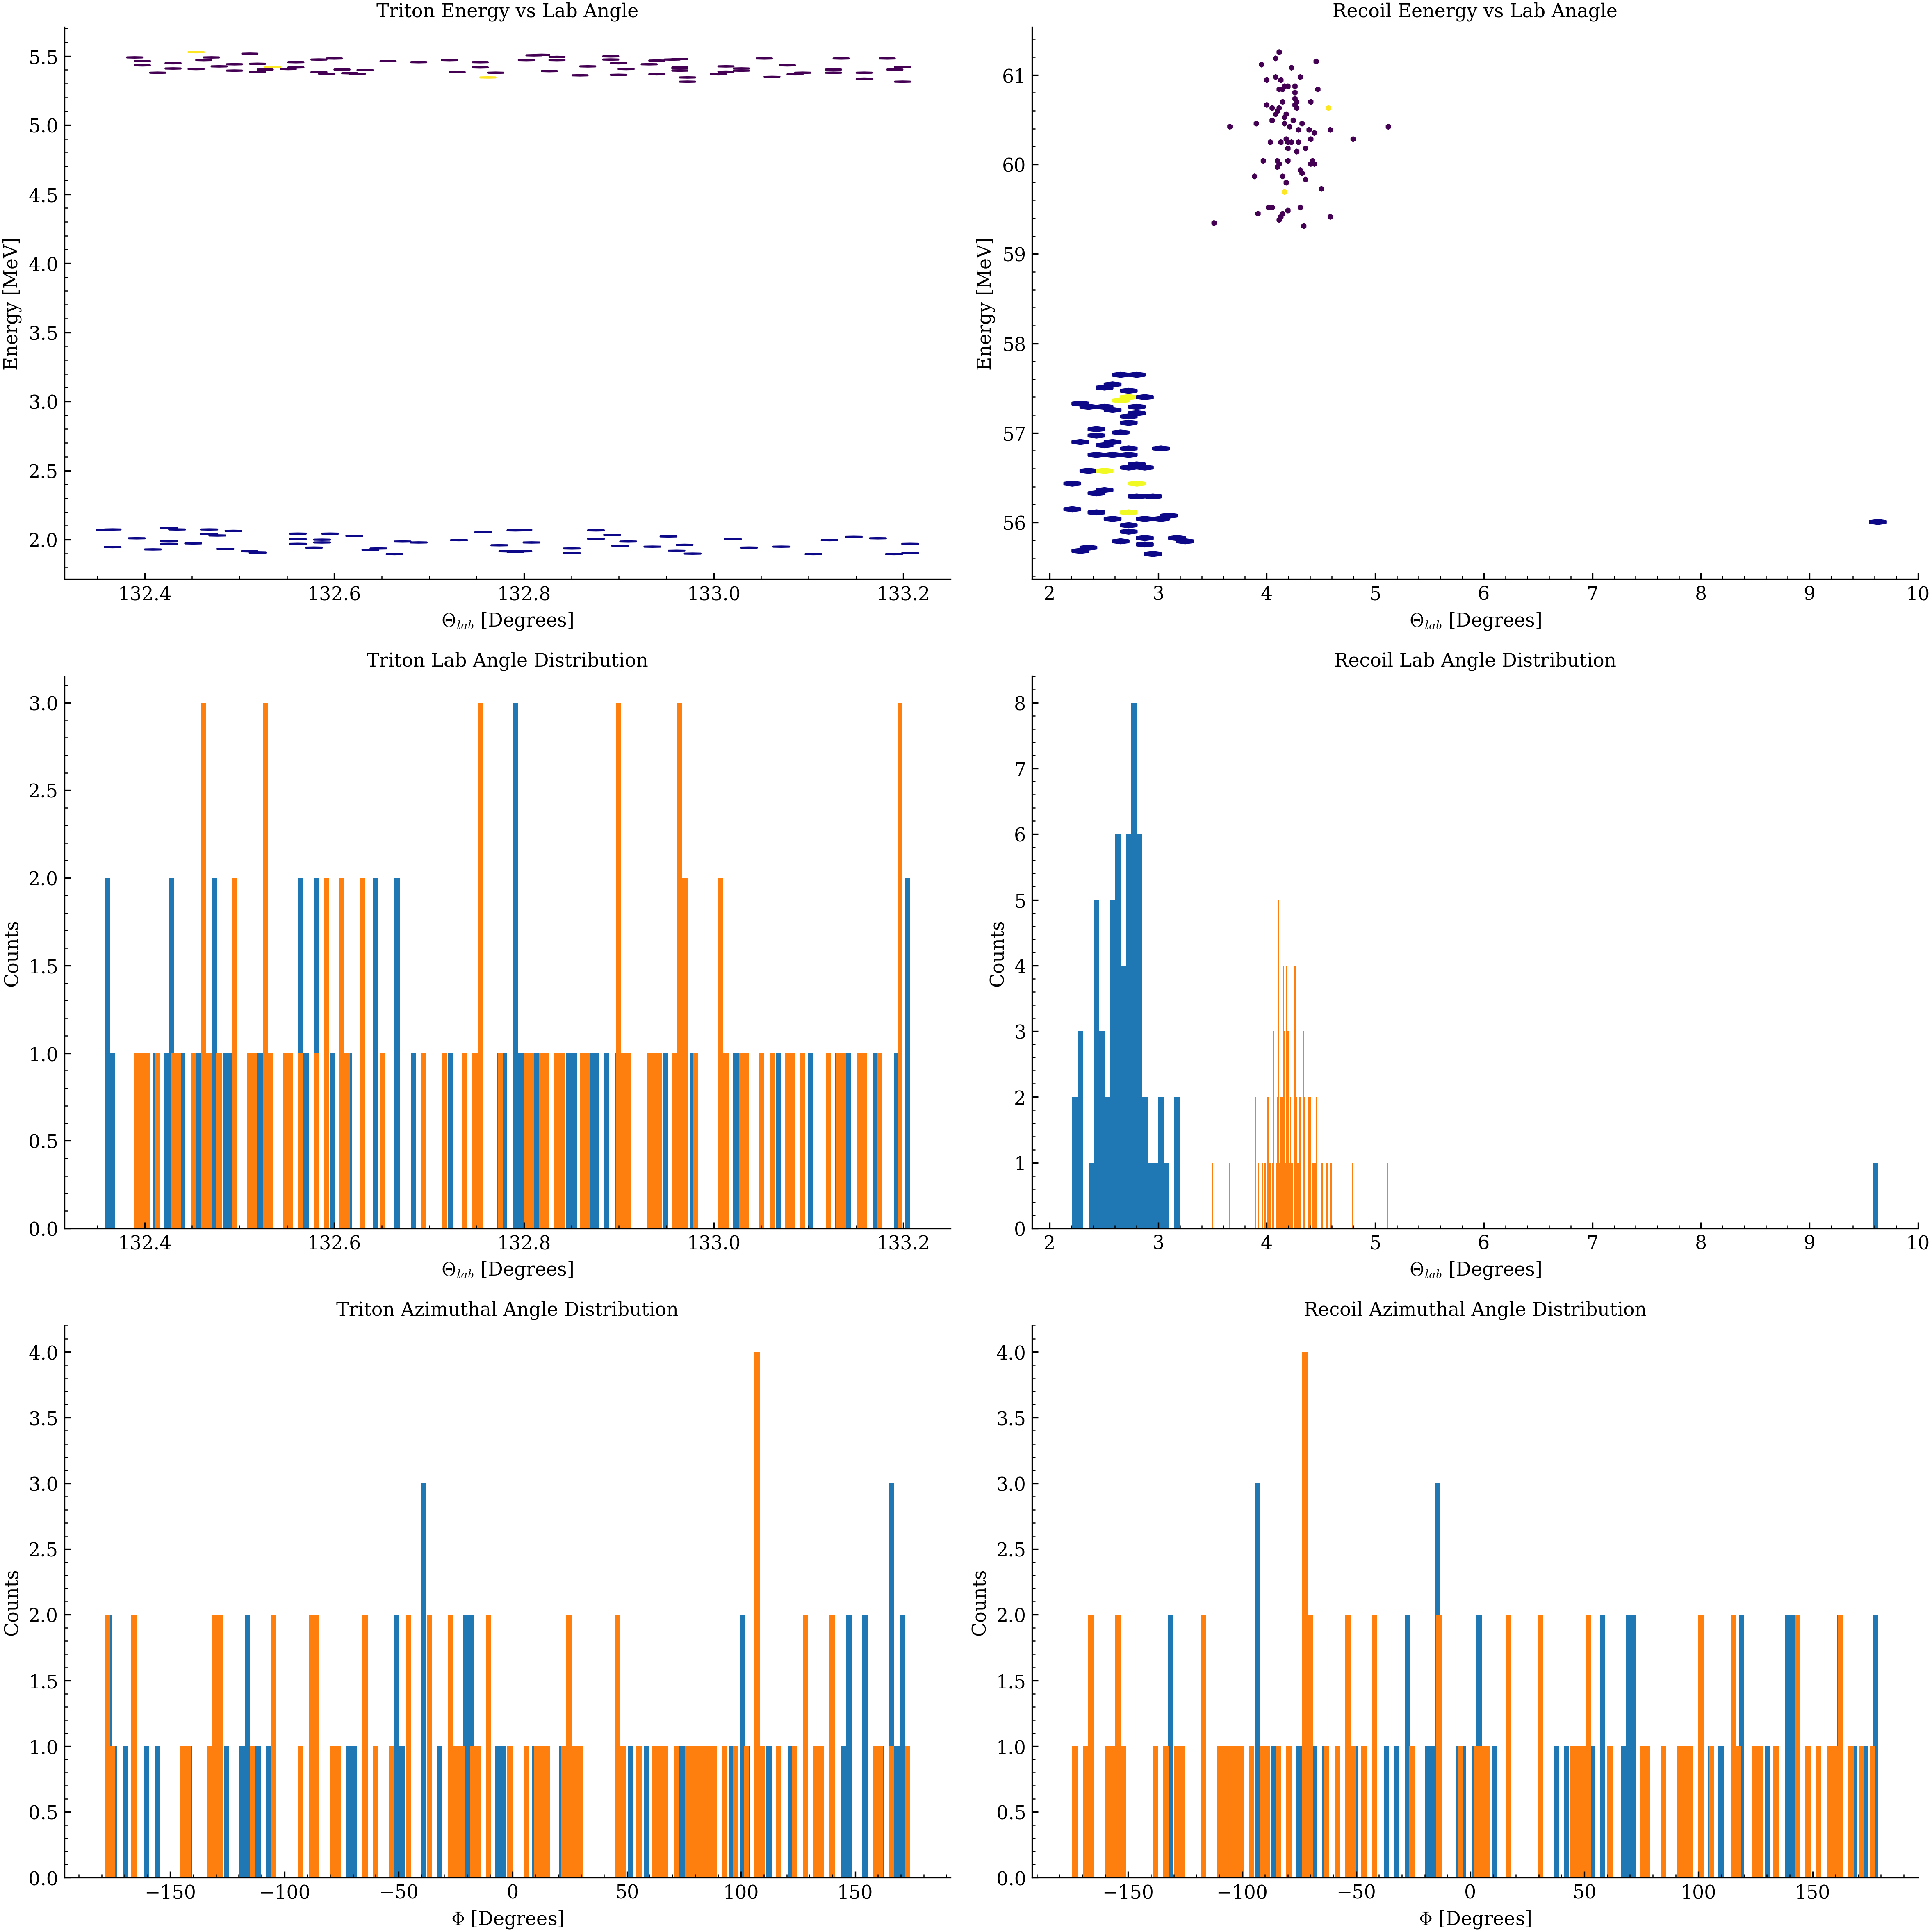

In [ ]:
# Now gate on a single ring and see the hits
theta_range = rings_theta[:2]  # outermost ring
bins = 150
# theta_range = [min(rings_theta), max(rings_theta)]

lo, hi = theta_range
index = np.where((Thetalab_t_11MeV > lo) & (Thetalab_t_11MeV < hi))[0]
index4 = np.where((Thetalab_t_4MeV > lo) & (Thetalab_t_4MeV < hi))[0]
index8 = np.where((Thetalab_t_8MeV > lo) & (Thetalab_t_8MeV < hi))[0]
index0 = np.where((Thetalab_t_0MeV > lo) & (Thetalab_t_0MeV < hi))[0]
index_gate = np.where((Thetalab_t_gate > lo) & (Thetalab_t_gate < hi))[0]

fig, ax = plt.subplots(3, 2,figsize=(16, 16))

ax[0, 0].hexbin(Thetalab_t_11MeV[index], E_t_11MeV[index], gridsize=50, cmap="plasma", mincnt=1)
ax[0, 0].hexbin(Thetalab_t_4MeV[index4], E_t_4MeV[index4], gridsize=50, mincnt=1)

ax[0, 1].hexbin(Thetalab_recoil_11MeV[index], E_recoil_11MeV[index], gridsize=50, cmap="plasma", mincnt=1)
ax[0, 1].hexbin(Thetalab_recoil_4MeV[index4], E_recoil_4MeV[index4], gridsize=50, mincnt=1)

ax[1, 1].hist(Thetalab_recoil_11MeV[index], bins = bins)
ax[1, 1].hist(Thetalab_recoil_4MeV[index4], bins = bins)

ax[1, 0].hist(Thetalab_t_11MeV[index], bins = bins)
ax[1, 0].hist(Thetalab_t_4MeV[index4], bins = bins)

ax[2, 0].hist(Philab_t_11MeV[index], bins = bins)
ax[2, 0].hist(Philab_t_4MeV[index4], bins = bins)

ax[2, 1].hist(Philab_recoil_11MeV[index], bins = bins)
ax[2, 1].hist(Philab_recoil_4MeV[index4], bins = bins)
# plt.hexbin(Thetalab_t, E_t,  gridsize=200, mincnt=1)
# plt.xlim(130, 160)
# plt.ylim(0, 5)
ax[0, 0].set_title("Triton Energy vs Lab Angle")
ax[0, 1].set_title("Recoil Eenergy vs Lab Anagle")
ax[1, 0].set_title("Triton Lab Angle Distribution")
ax[1, 1].set_title("Recoil Lab Angle Distribution")
ax[2, 0].set_title("Triton Azimuthal Angle Distribution")
ax[2, 1].set_title("Recoil Azimuthal Angle Distribution")

ax[0, 0].set_xlabel(r"$\Theta_{lab}$ [Degrees]")
ax[0, 0].set_ylabel("Energy [MeV]")


ax[0, 1].set_xlabel(r"$\Theta_{lab}$ [Degrees]")
ax[0, 1].set_ylabel("Energy [MeV]")

ax[1, 0].set_xlabel(r"$\Theta_{lab}$ [Degrees]")
ax[1, 0].set_ylabel("Counts")

ax[1, 1].set_xlabel(r"$\Theta_{lab}$ [Degrees]")
ax[1, 1].set_ylabel("Counts")

ax[2, 1].set_xlabel(r"$\Phi$ [Degrees]")
ax[2, 1].set_ylabel("Counts")

ax[2, 0].set_xlabel(r"$\Phi$ [Degrees]")
ax[2, 0].set_ylabel("Counts")
plt.tight_layout()

print(len(Thetalab_recoil_4MeV[index4]))



(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,
         0.,  1.,  0.,  0.,  0.,  0.,  1.,  1.,  0.,  0.,  1.,  0.,  0.,
         1.,  0.,  2.,  2.,  1.,  2.,  1.,  0.,  1.,  2.,  2.,  3.,  0.,
         2.,  5.,  1.,  9.,  5.,  7.,  5., 11., 10.,  8., 11., 16., 17.,
        21., 13., 21., 25., 19., 23., 22., 23., 23., 16., 25., 20., 20.,
         9., 20., 10., 17., 10.,  8., 11.,  6., 10.,  2.,  2.,  3.,  4.,
         3.,  1.,  4.,  1.,  1.,  3.,  1.,  2.,  1.,  0.,  1.,  4.,  1.,
         0.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.52938308, 0.55085814, 0.57233319, 0.59380825, 0.61528331,
        0.63675836, 0.65823342, 0.67970848, 0.70118354, 0.72265859,
        0.744133

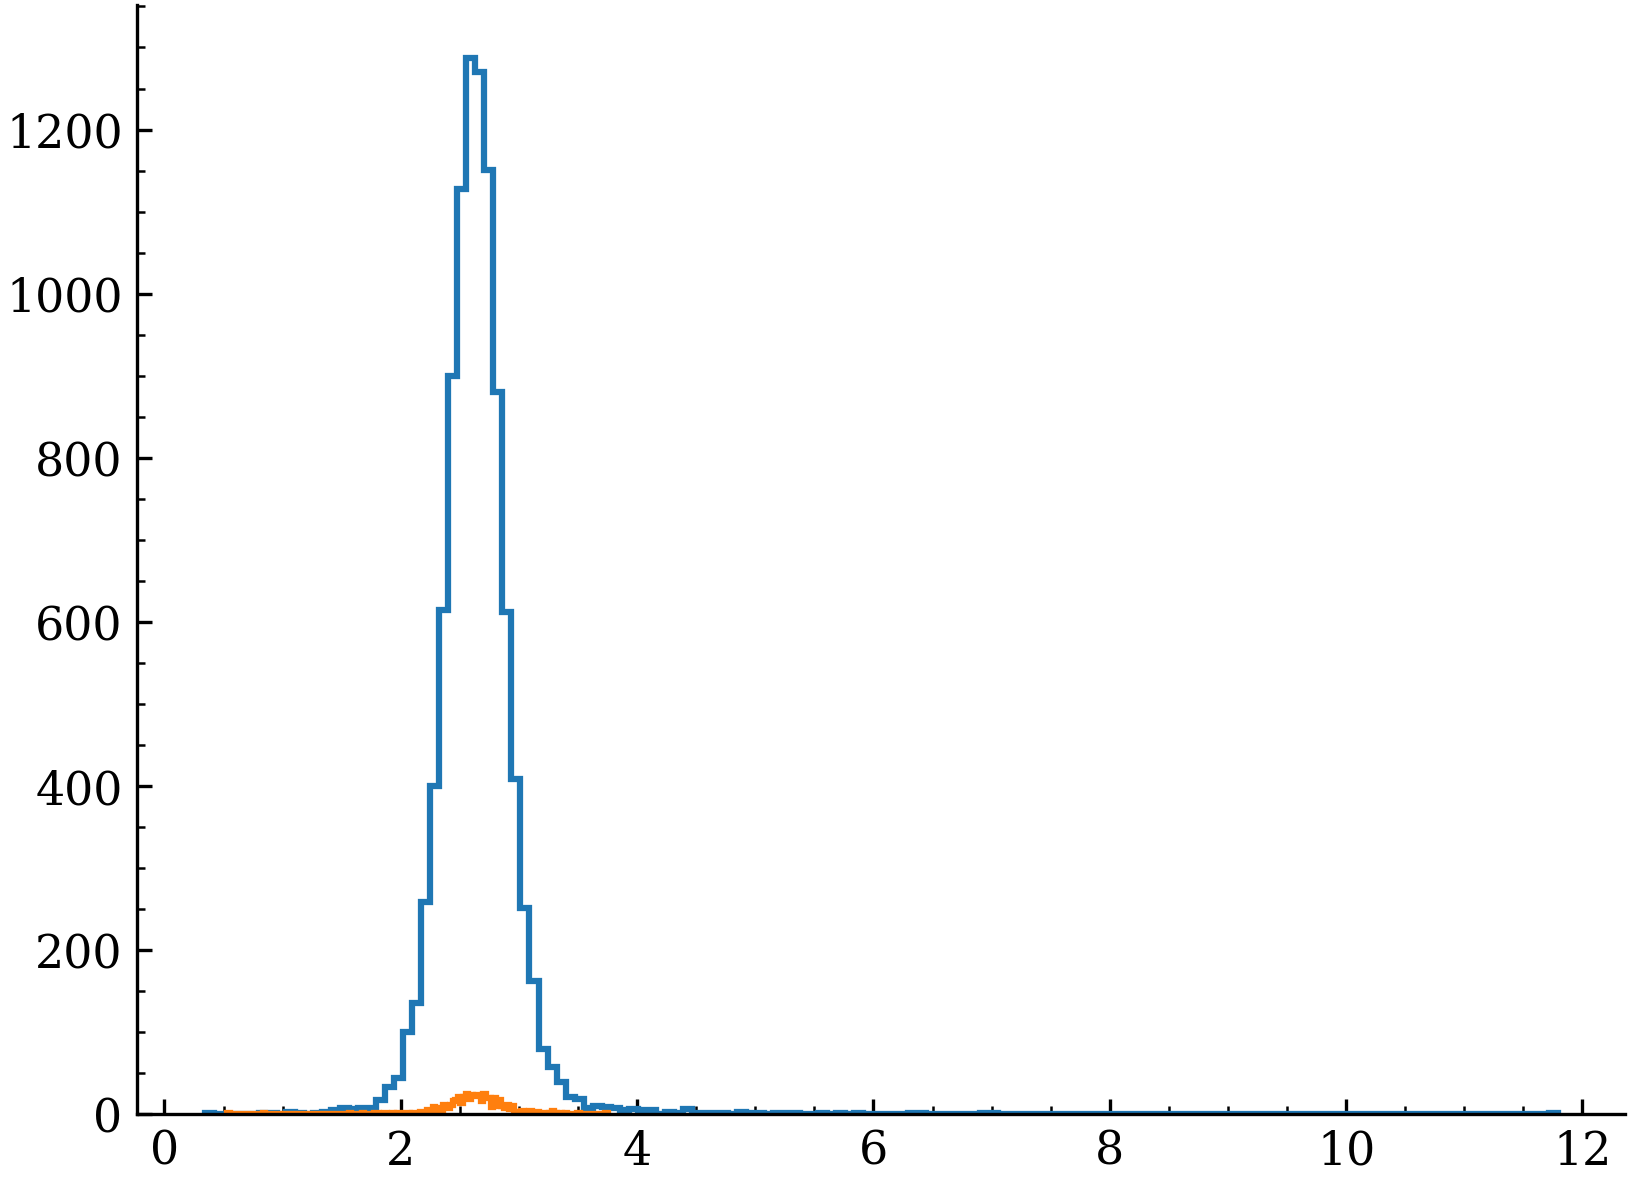

In [ ]:
plt.hist(Thetalab_recoil_gate_test, bins=bins, histtype="step", linewidth=1.5, label=r"$E_x=11$ MeV")

plt.hist(Thetalab_recoil_gate[index_gate], bins=bins, histtype="step", linewidth=1.5, label=r"$E_x=0$ MeV")

10000
10000


np.float64(6.25)

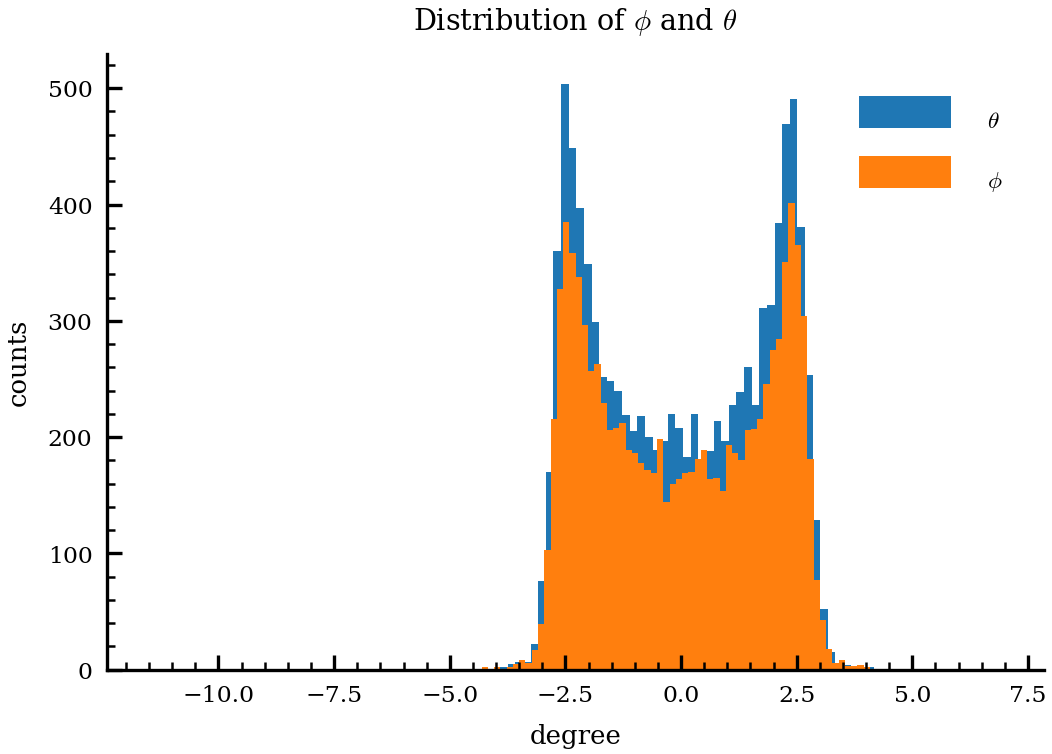

In [ ]:
Thetalab_recoil_rad = np.deg2rad(Thetalab_recoil_gate_test)
Philab_recoil_rad = np.deg2rad(Philab_recoil_gate_test)
bins = 100
# Phi = np.arctan2(uy, ux)
# plt.hist(np.arctan2(uy, ux), bins = 100)
fig = plt.figure(figsize=(4, 3))
# theta = np.arctan2(np.tan(Thetalab_recoil_rad) * np.cos(Philab_recoil_rad), np.cos(Thetalab_recoil_rad))  # in radians 
# phi = np.arctan2(np.tan(Thetalab_recoil_rad) * np.sin(Philab_recoil_rad), np.cos(Thetalab_recoil_rad))    # in radians 
theta = np.arctan(np.tan(Thetalab_recoil_rad) * np.cos(Philab_recoil_rad))
phi = np.arctan(np.tan(Thetalab_recoil_rad) * np.sin(Philab_recoil_rad))
counts, endges, patches = plt.hist(np.rad2deg(theta), bins = bins, label = r"$\theta$")
counts2, edges2, patches2  = plt.hist(np.rad2deg(phi), bins = bins, label = r"$\phi$")
plt.xlabel("degree")
plt.ylabel("counts")
plt.title(r"Distribution of $\phi$ and $\theta$")
plt.legend()
# print(counts)
# print(counts2)
# plt.xlim(-15, 15)
print(len(Philab_recoil_rad))
print(len(Thetalab_recoil_rad))
plt.tight_layout()
autoscale_fonts(fig, base=10)

ValueError: operands could not be broadcast together with shapes (10000,) (50005,) 

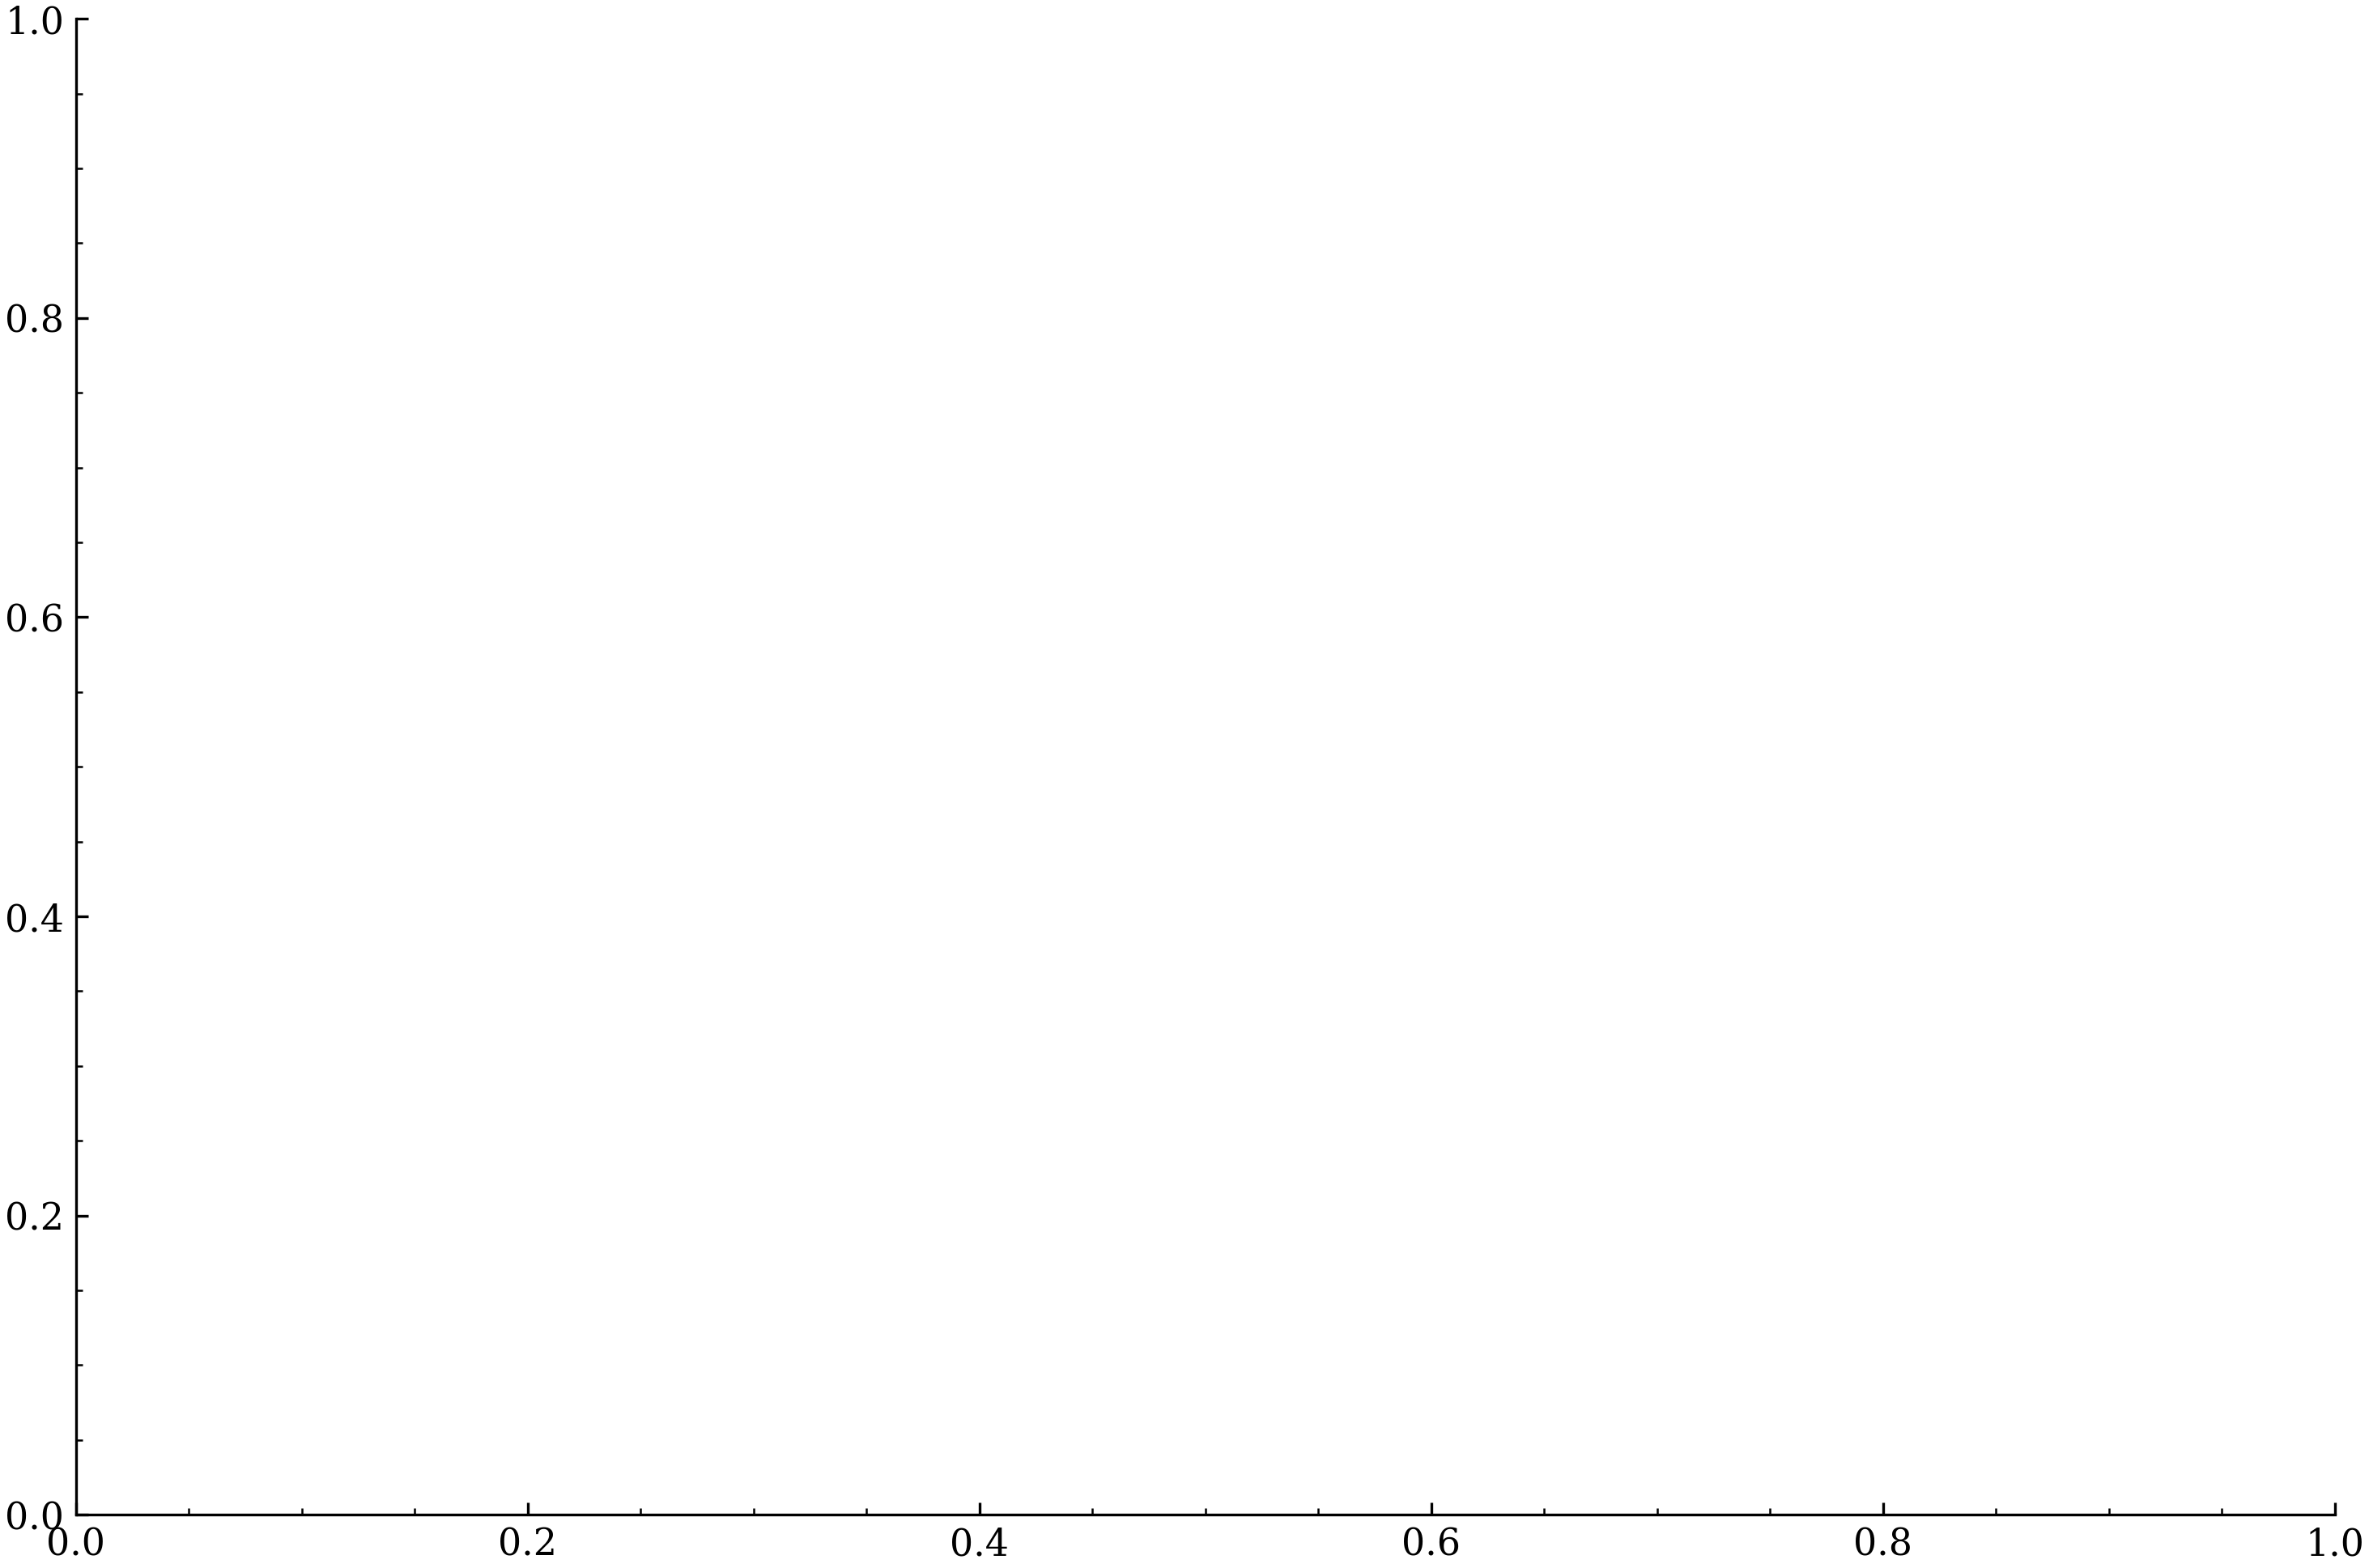

In [ ]:
Theta_rec = np.rad2deg(np.arctan(np.sqrt(np.tan(theta)**2 + np.tan(phi)**2)))
# Theta_rec = np.rad2deg(np.arctan2(np.sqrt(ux**2+uy**2), uz))
# plt.hexbin(np.rad2deg(theta), np.rad2deg(phi), gridsize=200, cmap="plasma", mincnt=1, label="Ex = 0 MeV")
plt.figure(figsize=(12, 8))
plt.hexbin(Theta_rec, E_recoil_11MeV, gridsize=200, cmap="plasma", mincnt=1, label="Ex = 0 MeV")
plt.title("Reconstructed Kinematics Curve")
plt.xlabel(r"Lab angle $\Theta$(degrees)")
plt.ylabel("Kinetic Energy")

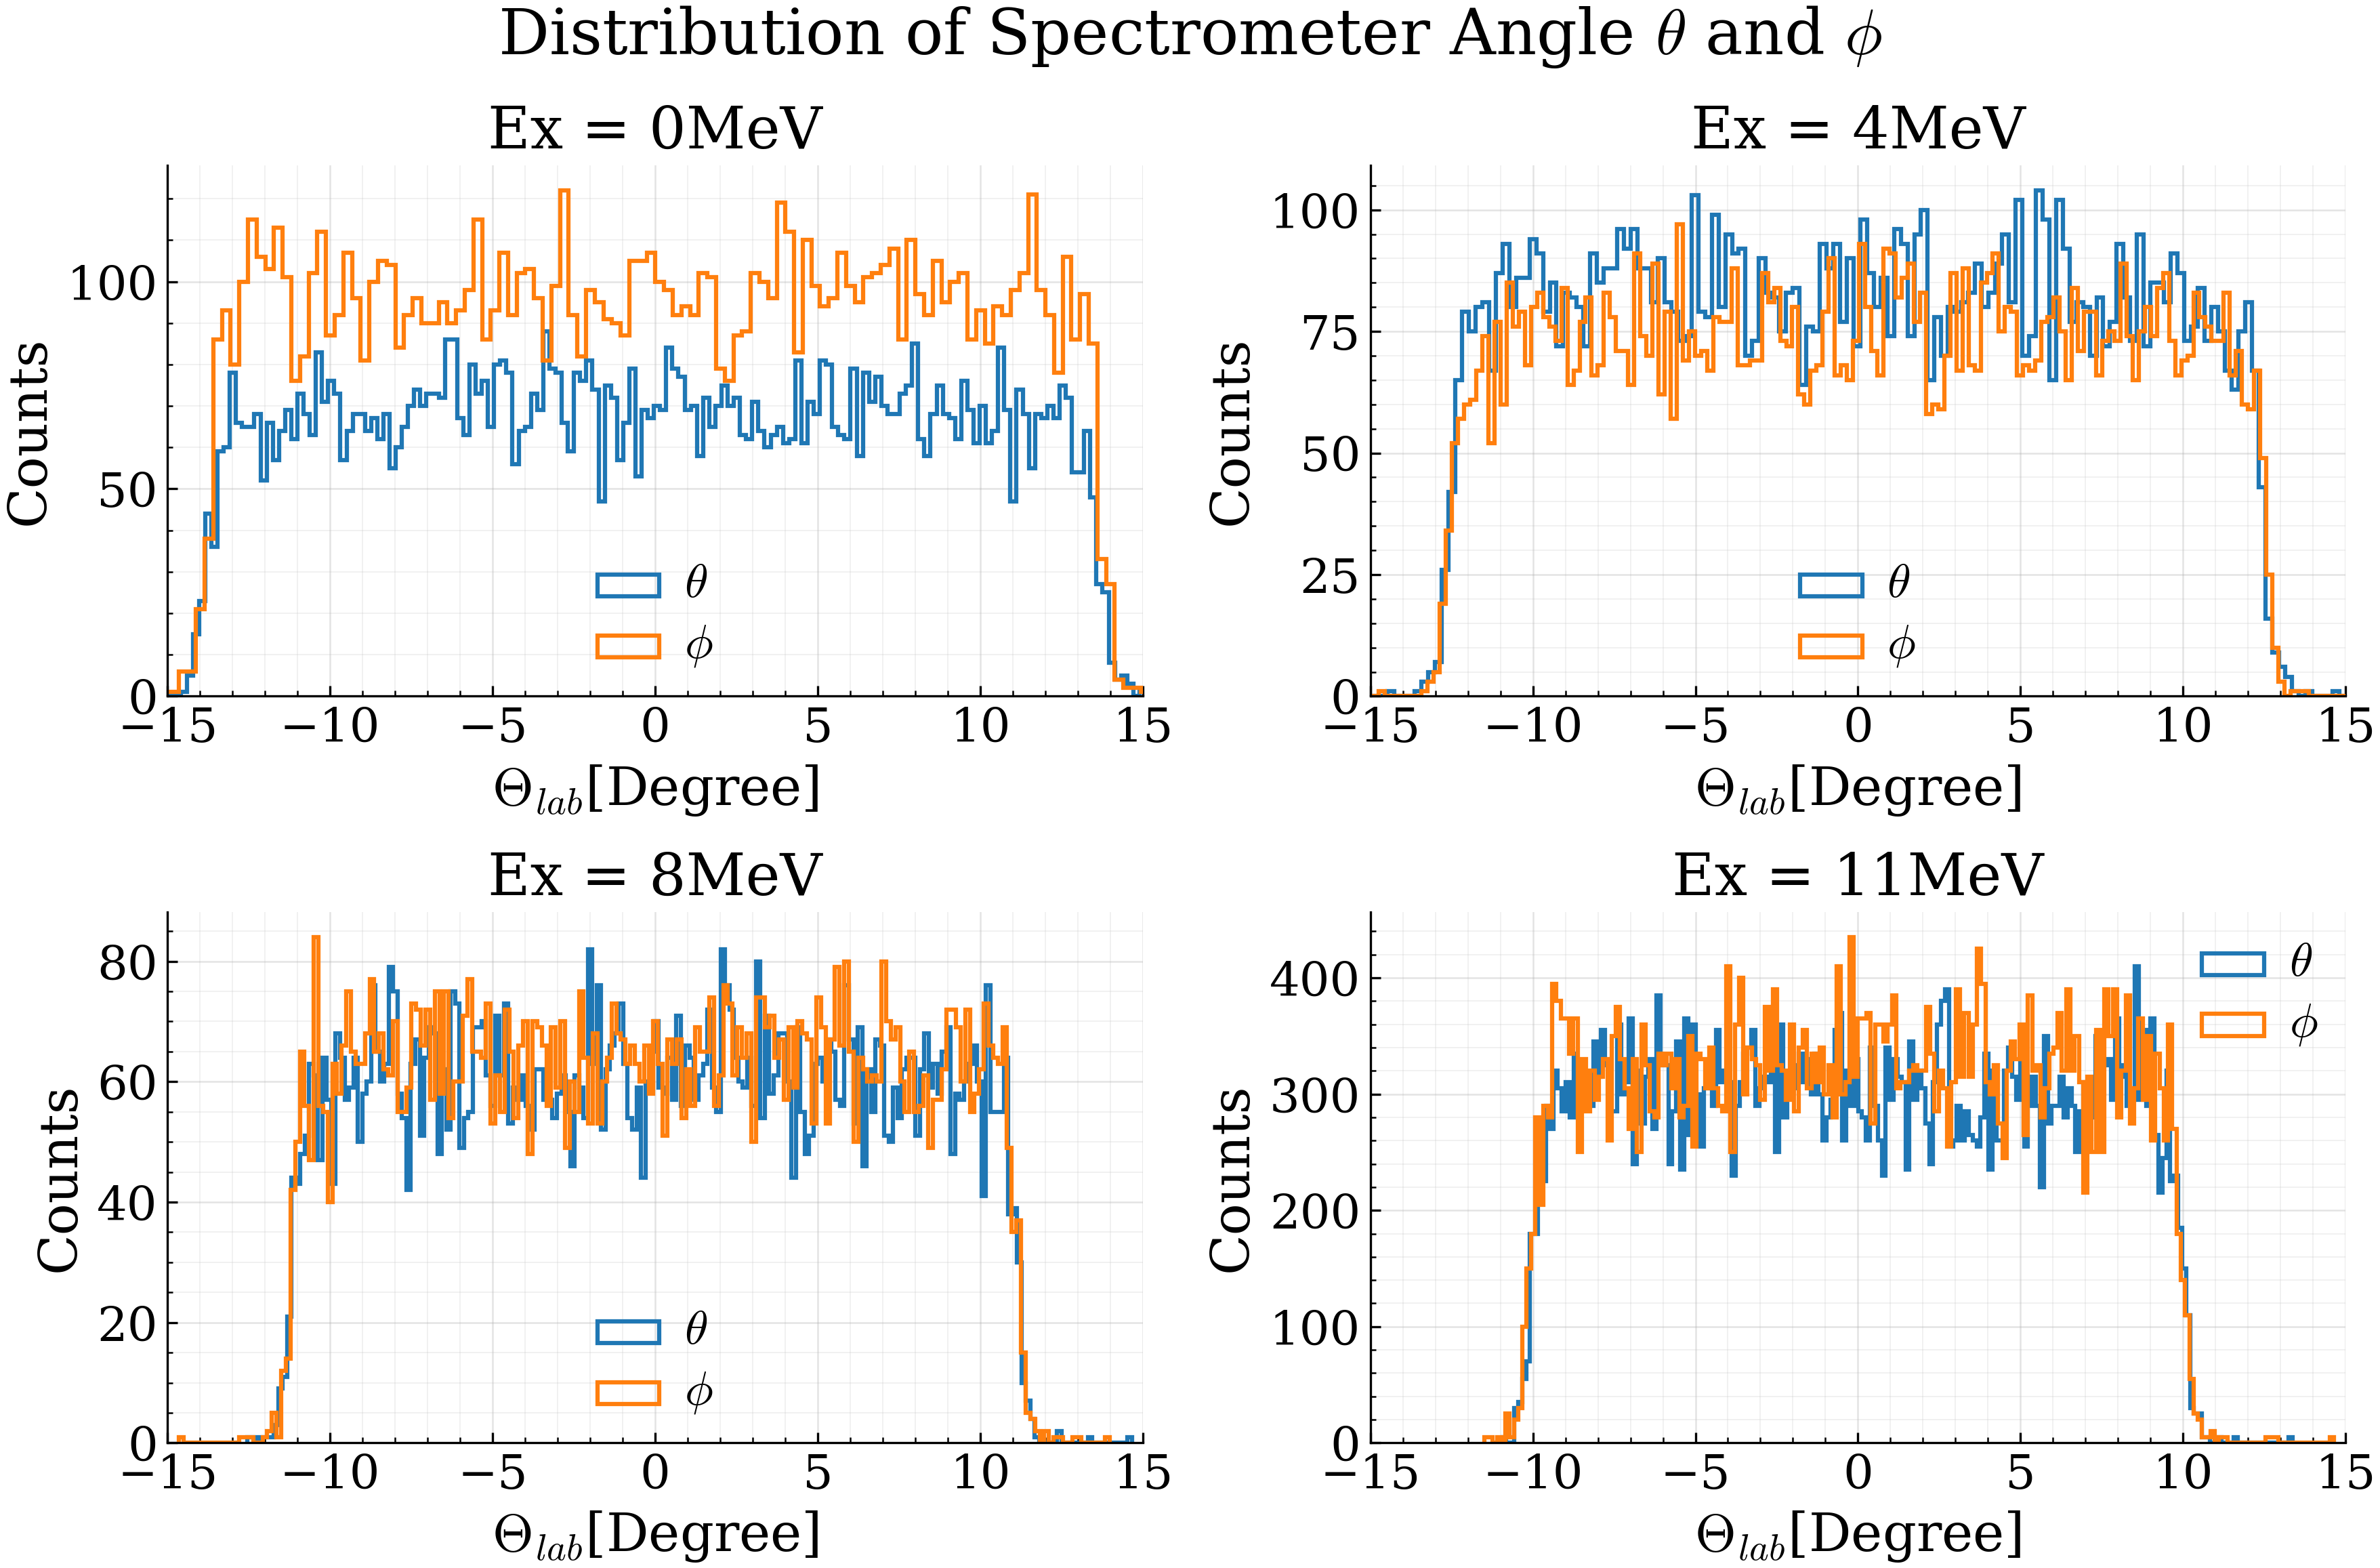

In [ ]:
# Investigating the spectrometer angle distributions: 
fig, ax = plt.subplots(2,2,figsize=(12, 8))
fig.suptitle(r"Distribution of Spectrometer Angle $\theta$ and $\phi$")  
def prettify(a):
    a.minorticks_on()
    a.grid(True, which="major", linewidth=0.6, alpha=0.35)
    a.grid(True, which="minor", linewidth=0.4, alpha=0.20)
    a.tick_params(which="both", top=False, right=False)

    
bins = 200

# Ex = 0 
Thetalab_recoil_rad = np.deg2rad(Thetalab_recoil_0MeV_test1)
Philab_recoil_rad = np.deg2rad(Philab_recoil_0MeV_test1)

theta = np.arctan(np.tan(Thetalab_recoil_rad) * np.cos(Philab_recoil_rad))
phi = np.arctan(np.tan(Thetalab_recoil_rad) * np.sin(Philab_recoil_rad))

ax[0, 0].hist(np.rad2deg(theta), bins=bins, histtype="step", linewidth=1.5, label=r"$\theta$")
ax[0, 0].hist(np.rad2deg(phi), bins=bins, histtype="step", linewidth=1.5, label=r"$\phi$")

#  Ex = 4
Thetalab_recoil_rad = np.deg2rad(Thetalab_recoil_4MeV_test1)
Philab_recoil_rad = np.deg2rad(Philab_recoil_4MeV_test1)

theta = np.arctan(np.tan(Thetalab_recoil_rad) * np.cos(Philab_recoil_rad))
phi = np.arctan(np.tan(Thetalab_recoil_rad) * np.sin(Philab_recoil_rad))

ax[0, 1].hist(np.rad2deg(theta), bins=bins, histtype="step", linewidth=1.5, label=r"$\theta$")
ax[0, 1].hist(np.rad2deg(phi), bins=bins, histtype="step", linewidth=1.5, label=r"$\phi$")

#  Ex = 8
Thetalab_recoil_rad = np.deg2rad(Thetalab_recoil_8MeV_test1)
Philab_recoil_rad = np.deg2rad(Philab_recoil_8MeV_test1)

theta = np.arctan(np.tan(Thetalab_recoil_rad) * np.cos(Philab_recoil_rad))
phi = np.arctan(np.tan(Thetalab_recoil_rad) * np.sin(Philab_recoil_rad))

ax[1, 0].hist(np.rad2deg(theta), bins=bins, histtype="step", linewidth=1.5, label=r"$\theta$")
ax[1, 0].hist(np.rad2deg(phi), bins=bins, histtype="step", linewidth=1.5, label=r"$\phi$")

#  Ex = 11
Thetalab_recoil_rad = np.deg2rad(Thetalab_recoil_11MeV_test)
Philab_recoil_rad = np.deg2rad(Philab_recoil_11MeV_test)

theta = np.arctan(np.tan(Thetalab_recoil_rad) * np.cos(Philab_recoil_rad))
phi = np.arctan(np.tan(Thetalab_recoil_rad) * np.sin(Philab_recoil_rad))

ax[1, 1].hist(np.rad2deg(theta), bins=bins, histtype="step", linewidth=1.5, label=r"$\theta$")
ax[1, 1].hist(np.rad2deg(phi), bins=bins, histtype="step", linewidth=1.5, label=r"$\phi$")

ax[0, 0].set_title("Ex = 0MeV")
ax[0, 1].set_title("Ex = 4MeV")
ax[1, 0].set_title("Ex = 8MeV")
ax[1, 1].set_title("Ex = 11MeV")

for i in ax.ravel(): 
    prettify(i)
    i.legend()
    i.set_xlabel(r"$\Theta_{lab}$[Degree]")
    i.set_ylabel("Counts")
    i.set_xbound(-15, 15)
    
autoscale_fonts(fig, base=10)
plt.tight_layout()
plt.savefig("ComparisonSpectrometerAngle.png")




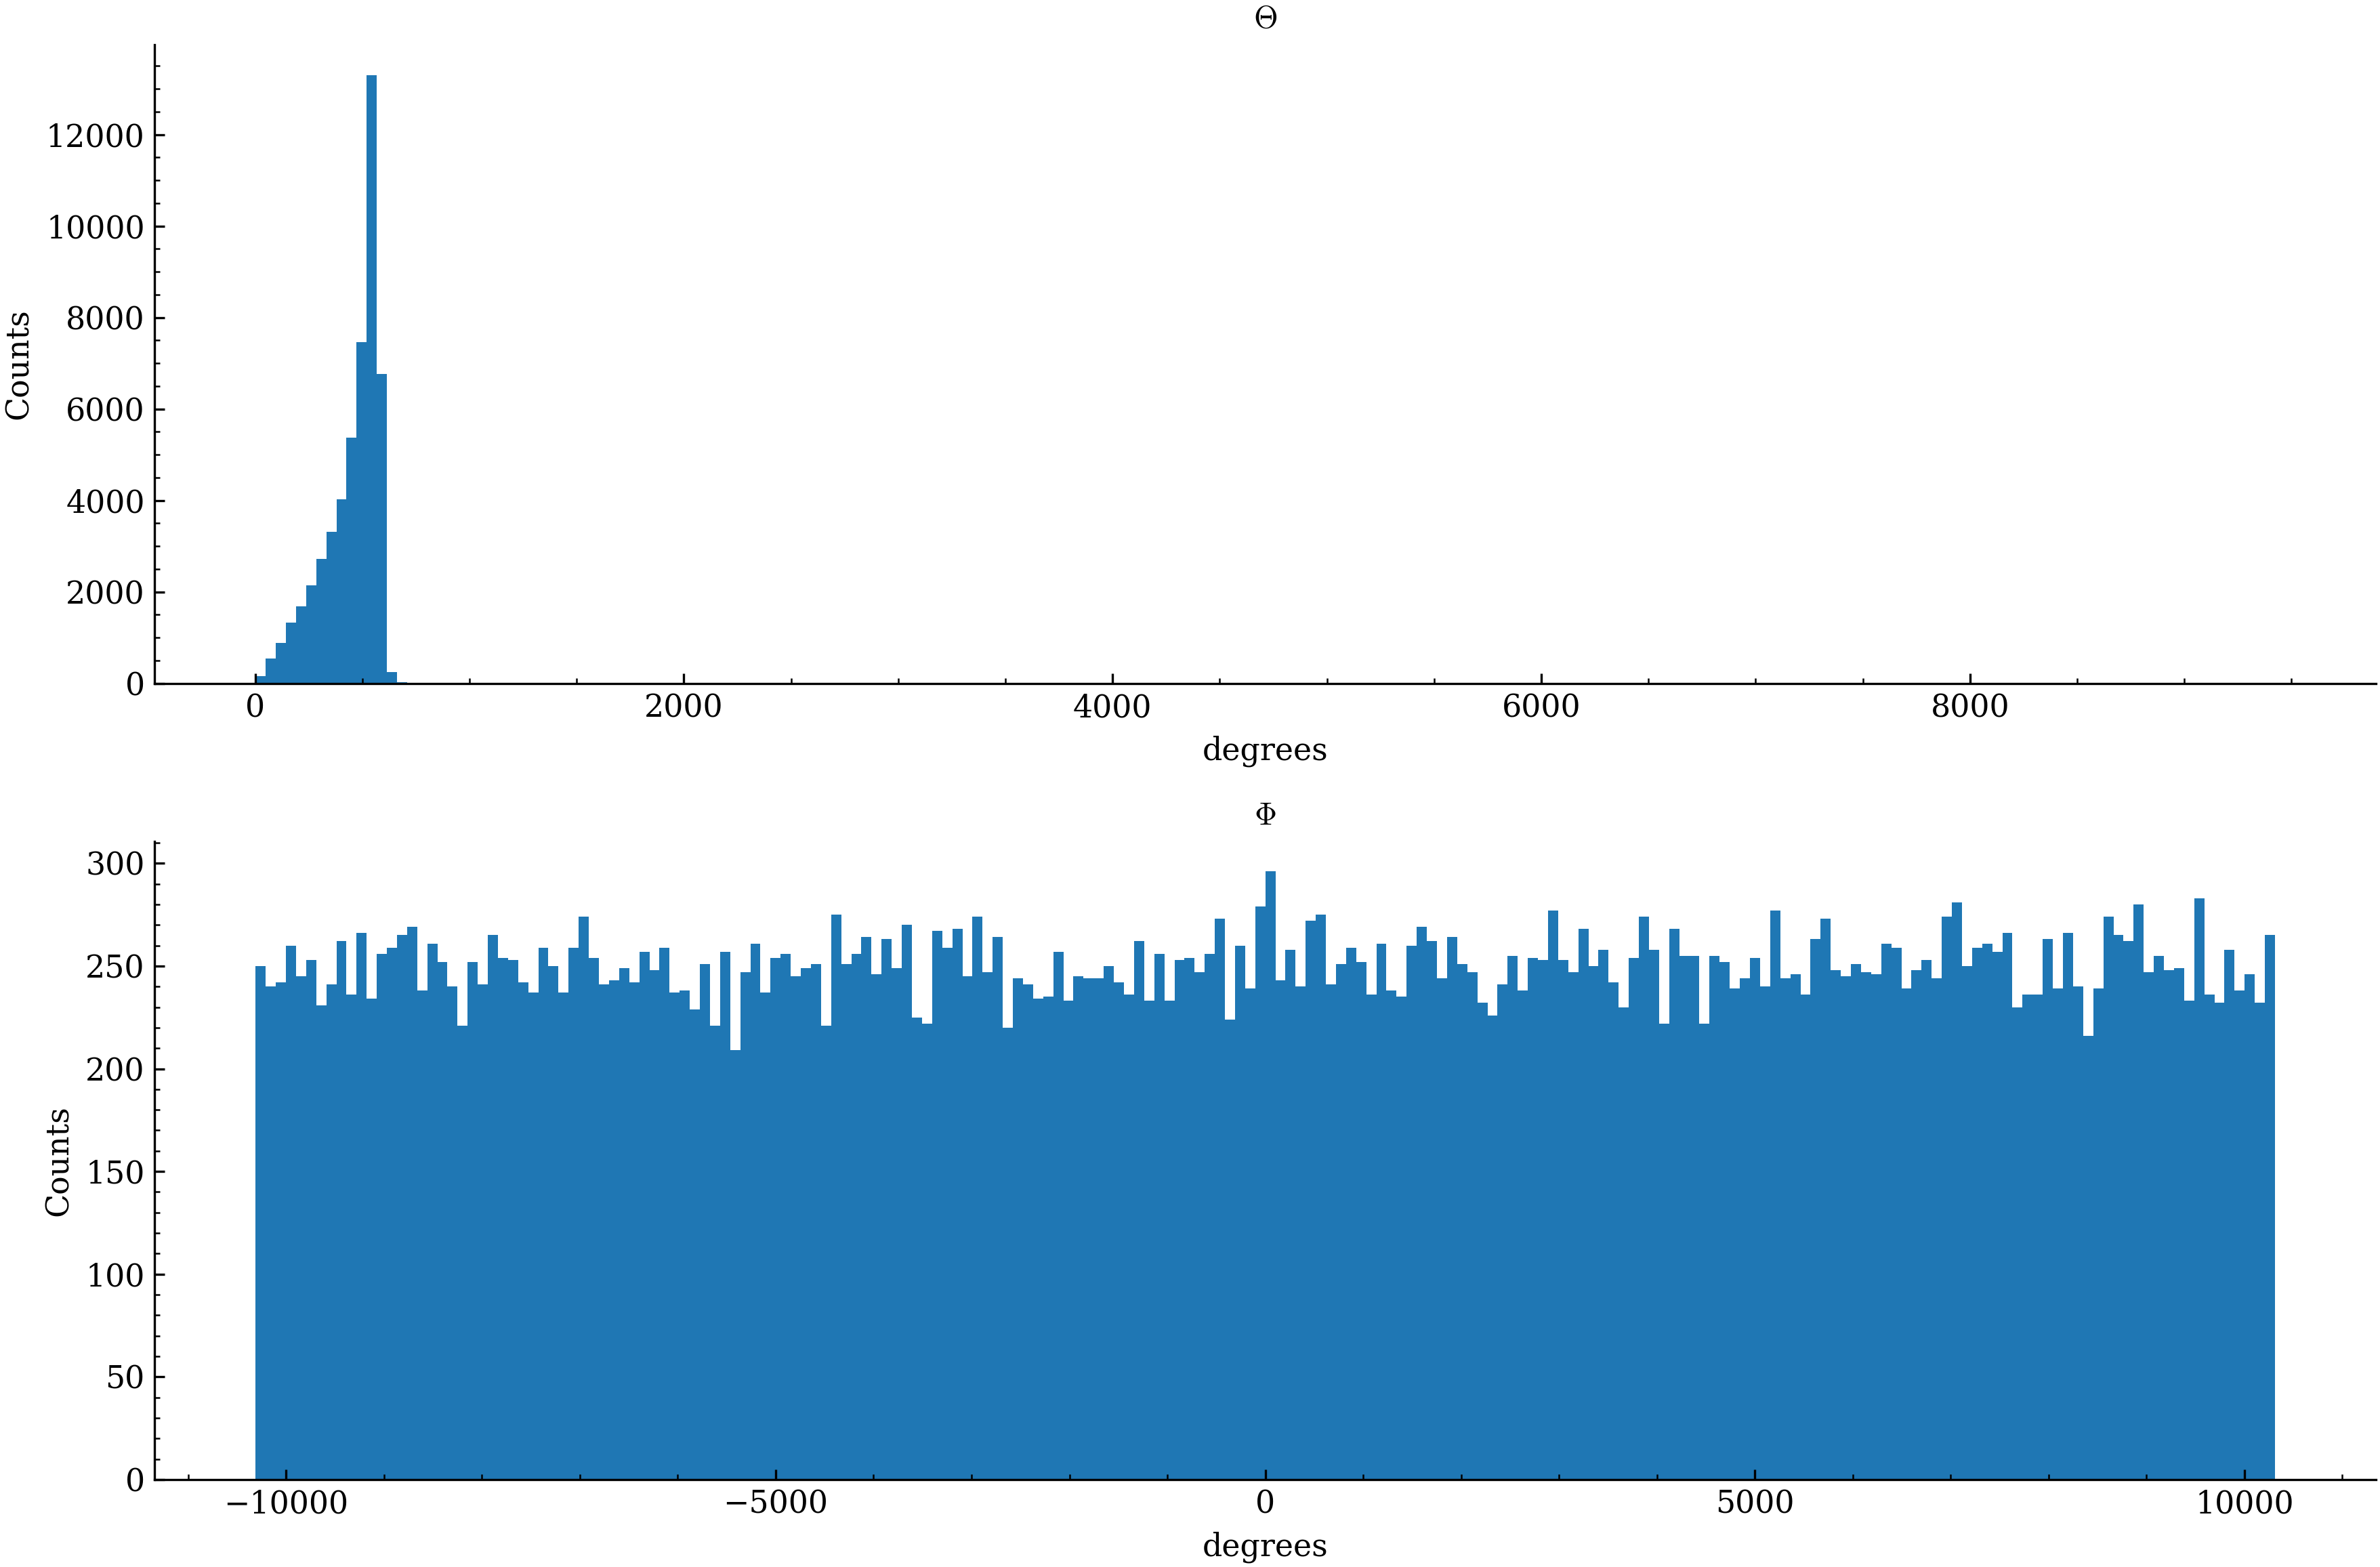

In [ ]:
fig, ax = plt.subplots(2, figsize=(12, 8))
ax[0].hist(np.rad2deg(Thetalab_recoil_11MeV), bins = bins)
# ax[0].hist(np.cos(np.deg2rad(ThetaCM_recoil)), bins = bins)
ax[1].hist(np.rad2deg(Philab_recoil_11MeV), bins = bins)
ax[0].set_title(r"$\Theta$")
ax[1].set_title(r"$\Phi$")
ax[0].set_xlabel("degrees")
ax[1].set_xlabel("degrees")
ax[0].set_ylabel("Counts")
ax[1].set_ylabel("Counts")
plt.tight_layout()


$$\theta = arctan(tan\Theta cos(\Phi))$$
$$\phi = arctan(tan\Theta sin(\Phi))$$

$$\Phi = arctan(tan(\phi) / tan(\theta)) $$
$$ tan^2 \Theta = tan^2 \theta + tan^2 \phi $$
$$ \theta = arctan(\sqrt {\frac {tan^2\Theta}{1 + tan^2 \Phi}}) $$
$$ \phi = arctan(tan\Phi \sqrt{\frac{tan^2(\Theta)}{1 + tan^2\Phi}})$$






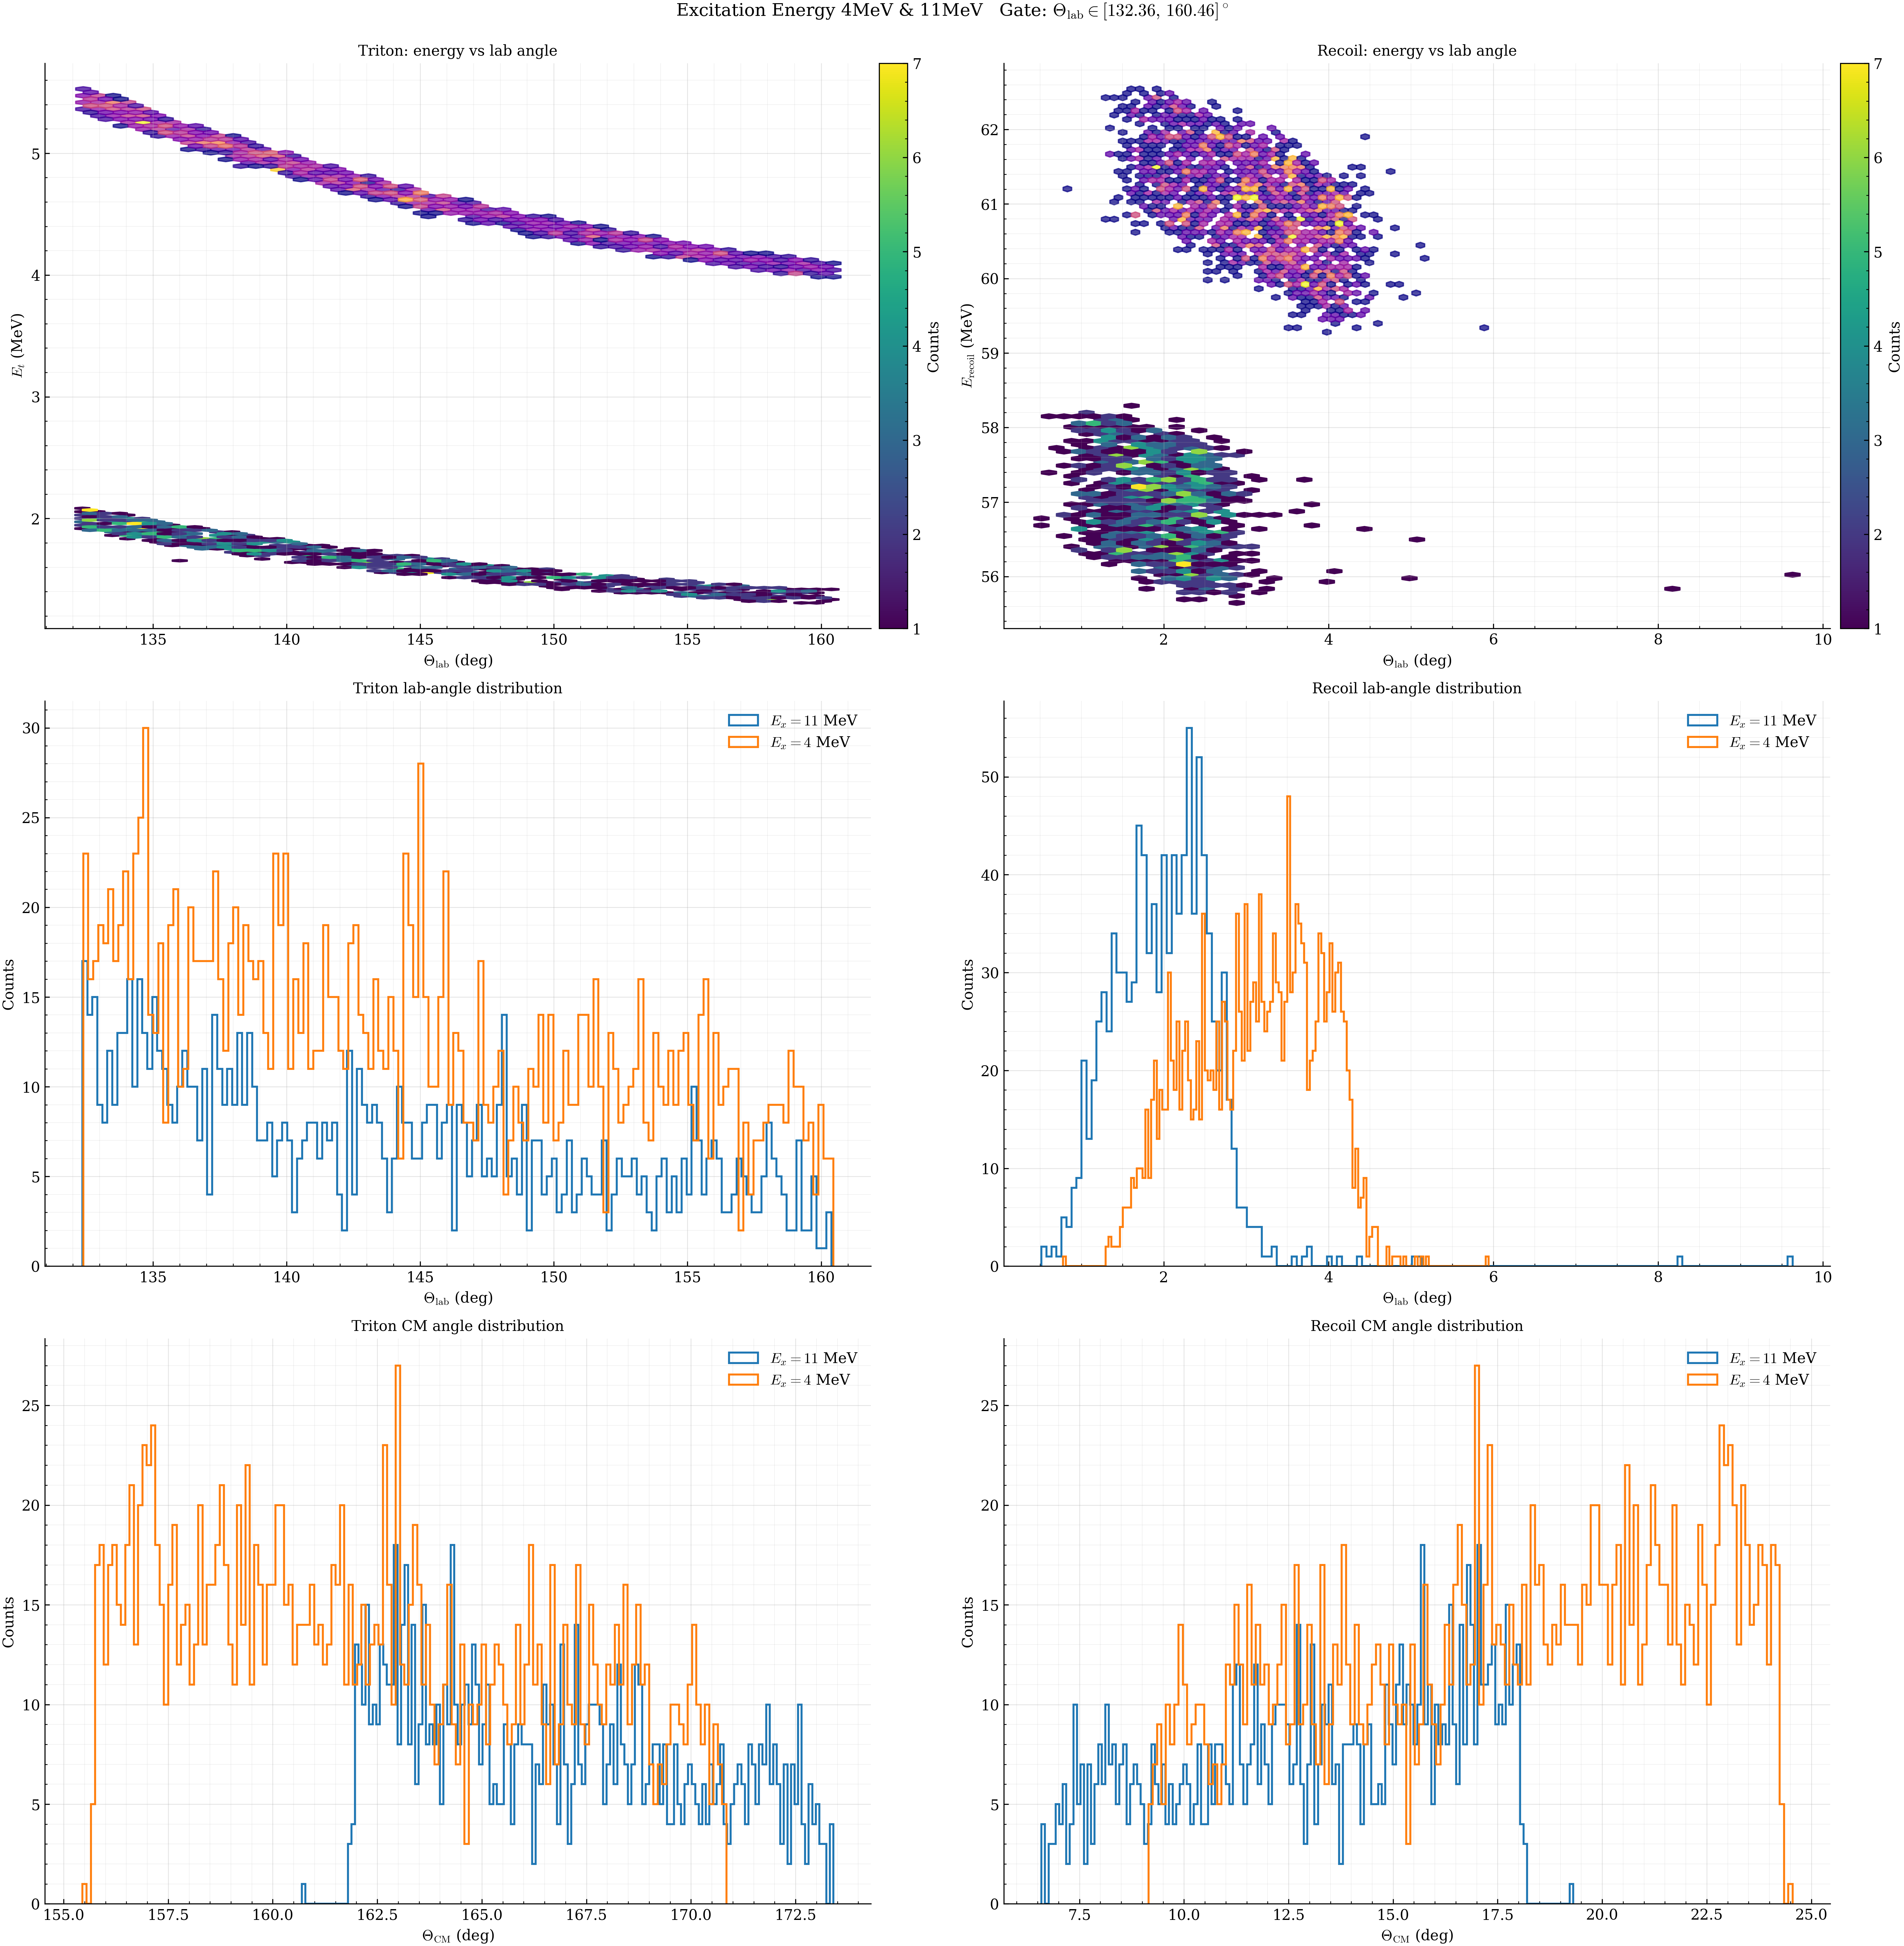

1935


<Figure size 1920x1440 with 0 Axes>

In [ ]:


# ---- Gate on a single ring ----
bins = 150
theta_range = [min(rings_theta), max(rings_theta)]
lo, hi = theta_range

index11 = np.where((Thetalab_t_11MeV > lo) & (Thetalab_t_11MeV < hi))[0]
index4  = np.where((Thetalab_t_4MeV  > lo) & (Thetalab_t_4MeV  < hi))[0]
index8  = np.where((Thetalab_t_8MeV  > lo) & (Thetalab_t_8MeV  < hi))[0]
index0  = np.where((Thetalab_t_0MeV  > lo) & (Thetalab_t_0MeV  < hi))[0]

# ---- Figure ----
fig, ax = plt.subplots(3, 2, figsize=(20, 20), constrained_layout=True)

# Helper: apply consistent axis cosmetics
def prettify(a):
    a.minorticks_on()
    a.grid(True, which="major", linewidth=0.6, alpha=0.35)
    a.grid(True, which="minor", linewidth=0.4, alpha=0.20)
    a.tick_params(which="both", top=False, right=False)

# ---- Top row: hexbin (use same cmap + same normalization for fair comparison) ----
# Find common min/max for consistent color scaling across the two overlays per panel
# (Counts per hex are not directly "comparable" between datasets unless sizes are similar,
#  but matching vmin/vmax makes the color meaning consistent within each panel.)
hb00_11 = ax[0, 0].hexbin(Thetalab_t_11MeV[index11], E_t_11MeV[index11],
                         gridsize=50, mincnt=1)
hb00_4  = ax[0, 0].hexbin(Thetalab_t_4MeV[index4],  E_t_4MeV[index4],
                         gridsize=50, cmap="plasma", mincnt=1, alpha=0.75)

hb01_11 = ax[0, 1].hexbin(Thetalab_recoil_11MeV[index11], E_recoil_11MeV[index11],
                         gridsize=50, mincnt=1)
hb01_4  = ax[0, 1].hexbin(Thetalab_recoil_4MeV[index4],  E_recoil_4MeV[index4],
                         gridsize=50, cmap="plasma", mincnt=1, alpha=0.75)

# Colorbars for the hexbin panels
cbar0 = fig.colorbar(hb00_11, ax=ax[0, 0], pad=0.01)
cbar0.set_label("Counts")
cbar1 = fig.colorbar(hb01_11, ax=ax[0, 1], pad=0.01)
cbar1.set_label("Counts")

# ---- Middle + bottom: histograms (overlay with transparency + legend) ----
ax[1, 0].hist(Thetalab_t_11MeV[index11], bins=bins, histtype="step", linewidth=1.5, label=r"$E_x=11$ MeV")
ax[1, 0].hist(Thetalab_t_4MeV[index4],  bins=bins, histtype="step", linewidth=1.5, label=r"$E_x=4$ MeV")
ax[1, 0].legend()

ax[1, 1].hist(Thetalab_recoil_11MeV[index11], bins=bins, histtype="step", linewidth=1.5, label=r"$E_x=11$ MeV")
ax[1, 1].hist(Thetalab_recoil_4MeV[index4],  bins=bins, histtype="step", linewidth=1.5, label=r"$E_x=4$ MeV")
ax[1, 1].legend()

ax[2, 0].hist(ThetaCM_t_11MeV[index11], bins=bins, histtype="step", linewidth=1.5, label=r"$E_x=11$ MeV")
ax[2, 0].hist(ThetaCM_t_4MeV[index4],  bins=bins, histtype="step", linewidth=1.5, label=r"$E_x=4$ MeV")
ax[2, 0].legend()

ax[2, 1].hist(ThetaCM_recoil_11MeV[index11], bins=bins, histtype="step", linewidth=1.5, label=r"$E_x=11$ MeV")
ax[2, 1].hist(ThetaCM_recoil_4MeV[index4],  bins=bins, histtype="step", linewidth=1.5, label=r"$E_x=4$ MeV")
ax[2, 1].legend()

# ---- Titles + labels (clean, consistent) ----
ax[0, 0].set_title("Triton: energy vs lab angle")
ax[0, 1].set_title("Recoil: energy vs lab angle")
ax[1, 0].set_title("Triton lab-angle distribution")
ax[1, 1].set_title("Recoil lab-angle distribution")
ax[2, 0].set_title("Triton CM angle distribution")
ax[2, 1].set_title("Recoil CM angle distribution")

ax[0, 0].set_xlabel(r"$\Theta_{\mathrm{lab}}$ (deg)")
ax[0, 0].set_ylabel(r"$E_t$ (MeV)")

ax[0, 1].set_xlabel(r"$\Theta_{\mathrm{lab}}$ (deg)")
ax[0, 1].set_ylabel(r"$E_{\mathrm{recoil}}$ (MeV)")

ax[1, 0].set_xlabel(r"$\Theta_{\mathrm{lab}}$ (deg)")
ax[1, 0].set_ylabel("Counts")

ax[1, 1].set_xlabel(r"$\Theta_{\mathrm{lab}}$ (deg)")
ax[1, 1].set_ylabel("Counts")

ax[2, 0].set_xlabel(r"$\Theta_{\mathrm{CM}}$ (deg)")
ax[2, 0].set_ylabel("Counts")

ax[2, 1].set_xlabel(r"$\Theta_{\mathrm{CM}}$ (deg)")
ax[2, 1].set_ylabel("Counts")

# ---- Apply cosmetics (grid + minors) ----
for a in ax.ravel():
    prettify(a)

# Optional: figure-level title that includes your gate
fig.suptitle(rf"Excitation Energy 4MeV & 11MeV   Gate: $\Theta_{{\mathrm{{lab}}}} \in [{lo:.2f},\,{hi:.2f}]^\circ$", y=1.02)
plt.savefig("S3gate1.png")
plt.show()
autoscale_fonts(fig, base=10)
plt.tight_layout()


print(len(Thetalab_recoil_4MeV[index4]))

